# Quranic Recitation Mistake Prediction Model

Dalam tugas akhir ini akan dilalui beberapa tahapan untuk mencapai model terbaik, dimulai dari pre-processing ekstraksi fitur, pembuatan model, hingga evaluasi model. Pada Gambar 3.2 dijabarkan setiap tahapan pada penelitian ini dalam bentuk diagram alir.

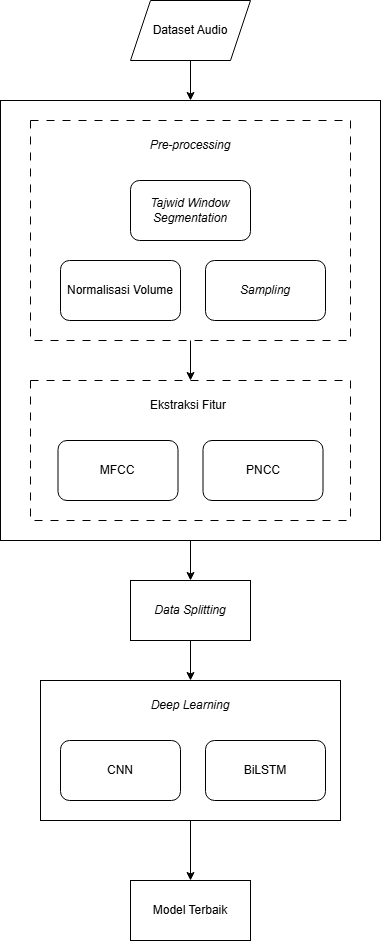

# Konfigurasi Awal

## Konfigurasi Dependensi

In [144]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tempfile
import soundfile as sf
from sklearn.model_selection import train_test_split, GroupKFold
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Flatten, Dropout, Input, BatchNormalization, Bidirectional, Concatenate, Dense
from scipy.fftpack import dct
from tensorflow.keras.metrics import Precision, Recall, CategoricalAccuracy
from sklearn.metrics import f1_score
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import EarlyStopping

## Konfigurasi Direktori

In [145]:
data_dir = "/kaggle/input/datasets/ahmadfatihr/quranic-recitation-for-application-dataset/audio/audio"
csv_path = "/kaggle/input/datasets/ahmadfatihr/quranic-recitation-for-application-dataset/timestampta.csv"

## Load File Audio

In [146]:
wav_files = [f for f in os.listdir(data_dir) if f.lower().endswith('.wav')]
print(f"Found {len(wav_files)} .wav files in: {data_dir}")
print("Sample files:", wav_files[:30])

Found 2402 .wav files in: /kaggle/input/datasets/ahmadfatihr/quranic-recitation-for-application-dataset/audio/audio
Sample files: ['Y_41 20260318-174805.wav', 'Z_19 20260317-041416.wav', 'M_5.wav', 'R_96.wav', 'AL_51 20260317-011801.wav', 'V_113b 20260320-193025.wav', 'K_87.wav', 'A_94 20260324-133705.wav', 'AL_95.wav', 'K_46.wav', 'R_82.wav', 'W_22.wav', 'V_31.wav', 'H_109.wav', 'K_108.wav', 'Q_109 20260419-205056.wav', 'Q_88.wav', 'L_102.wav', 'M_18.wav', 'K_39.wav', 'X_72.wav', 'L_38.wav', 'J_108.wav', 'Q_108.wav', 'R_108.wav', 'F_59.wav', 'N_32.wav', 'Q_41.wav', 'F_113 20260428-163846.wav', 'H_71 20260317-004859.wav']


# Preprocessing

Check for empty or silent window before extraction

In [147]:
def is_valid_audio(window_audio):
    return window_audio is not None and len(window_audio) > 0 and np.any(window_audio)

## Normalisasi Volume

In [148]:
def normalize_volume(y, target_dBFS=-20):
    import numpy as np
    rms = np.sqrt(np.mean(y**2)) # Root Mean Square (RMS) of the audio signal
    if rms == 0: # Sinyal Sunyi
        return y 
    current_dBFS = 20 * np.log10(rms) # Rumus dBFS awal
    gain = target_dBFS - current_dBFS # Selisih gain
    y_normalized = y * (10 ** (gain / 20)) # Apply gain sebagai rasio amplitudo
    return y_normalized

## Resampling

In [149]:
def resample_audio(y, orig_sr, target_sr=16000):
    import librosa
    if orig_sr == target_sr:
        return y, orig_sr
    y_resampled = librosa.resample(y, orig_sr=orig_sr, target_sr=target_sr)
    return y_resampled, target_sr

## Tajwid Segmentation

In [150]:
def segment_tajwid_windows(y, sr, window_segments, file_name, debug=False):
    segments = []
    suspicious_segments = []

    # Extract just the label part before the space and remove .wav extension
    # Examples: 'B_1 20260325.wav' → 'b_1', 'AL_98.wav' → 'al_98'
    file_base = file_name.split(' ')[0].lower()
    if file_base.endswith('.wav'):
        file_base = file_base[:-4]

    audio_len = len(y)
    audio_duration = audio_len / sr if sr else 0

    for seg in window_segments:
        label_norm = str(seg.get('label', '')).lower().strip()
        if label_norm != file_base:
            continue

        start_time = seg.get('start', None)
        end_time = seg.get('end', None)

        reason = None
        if start_time is None or end_time is None:
            reason = 'missing start/end timestamp'
        elif pd.isna(start_time) or pd.isna(end_time):
            reason = 'NaN start/end timestamp'
        elif end_time <= start_time:
            reason = f'invalid range (start={start_time}, end={end_time})'
        elif start_time < 0:
            reason = f'negative start time (start={start_time}, end={end_time})'
        elif start_time >= audio_duration:
            reason = f'start beyond audio duration (start={start_time}, audio_duration={audio_duration:.2f}s)'

        if reason is not None:
            suspicious_segments.append((file_name, label_norm, start_time, end_time, reason))
            continue

        start_sample = int(start_time * sr)
        end_sample = int(end_time * sr)
        start_sample = max(0, min(start_sample, audio_len))
        end_sample = max(0, min(end_sample, audio_len))

        if end_sample <= start_sample:
            suspicious_segments.append((file_name, label_norm, start_time, end_time, f'empty sample window ({start_sample}:{end_sample})'))
            continue

        window = y[start_sample:end_sample]
        if window is None or len(window) == 0:
            suspicious_segments.append((file_name, label_norm, start_time, end_time, 'empty extracted window'))
            continue

        segments.append((window, seg.get('label', ''), start_time, end_time))

    if debug:
        if suspicious_segments:
            print(f"⚠ {file_name:40} → suspicious CSV timestamp(s) found")
            for _, label_norm, start_time, end_time, reason in suspicious_segments:
                print(f"    - {label_norm}: start={start_time}, end={end_time} | {reason}")
        elif segments:
            print(f"✓ {file_name:40} → {len(segments)} valid CSV segment(s)")
        else:
            print(f"○ {file_name:40} → no matching CSV segment(s)")

    return segments

# Ekstraksi Fitur

In [151]:
def extract_file_label(file_name):
    file_base = file_name.split(' ')[0]  # Remove timestamp if present
    if file_base.endswith('.wav'):
        file_base = file_base[:-4]
    return file_base

def extract_speaker_group(file_name):
    file_label = extract_file_label(file_name)
    speaker_prefix = file_label.split('_')[0].strip()
    return speaker_prefix.lower()


## MFCC

In [152]:
def extract_mfcc(file_path, n_mfcc=13, max_len=100):
    import librosa
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # Pad or truncate to max_len
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0,0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

## PNCC

In [153]:
def extract_pncc(file_path, n_pncc=13, max_len=100):
    # Load audio
    y, sr = librosa.load(file_path, sr=None)
    if y is None or len(y) == 0:
        # Return zeros if audio is empty to avoid IndexError
        return np.zeros((n_pncc, max_len))
    
    # Pre-emphasis filter
    pre_emphasis = 0.97
    y = np.append(y[0], y[1:] - pre_emphasis * y[:-1])
    
    # Compute power spectrogram
    n_fft = 512
    hop_length = 160
    
    # STFT
    stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    power_spec = np.abs(stft) ** 2
    
    # Mel filterbank
    n_mels = 40
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels)
    mel_spec = np.dot(mel_basis, power_spec)
    
    # Power normalization (medium-time processing)
    mel_spec = mel_spec / (np.mean(mel_spec, axis=1, keepdims=True) + 1e-8)
    
    # Log compression
    mel_spec = np.log(mel_spec + 1e-8)
    
    # DCT (Discrete Cosine Transform) to get cepstral coefficients
    pncc = dct(mel_spec, type=2, axis=0, norm='ortho')[:n_pncc]
    
    # Normalize length
    if pncc.shape[1] < max_len:
        pad_width = max_len - pncc.shape[1]
        pncc = np.pad(pncc, pad_width=((0,0), (0, pad_width)), mode='constant')
    else:
        pncc = pncc[:, :max_len]
    
    return pncc

# Augmentasi Data

In [154]:
import random
import os
import tempfile
import soundfile as sf
import numpy as np
import librosa

def preprocess_and_augment_audio(audio, sr, label_key, labels_dict, num_classes,
                                 enable_augmentation=True, 
                                 minority_labels=set(['idgham bighunnah error','idgham bilaghunnah error','iqlab error','izhar error']),
                                 pitch_steps=[-2, -1, 1, 2], n_pitch=2, n_stretch=2, n_noise=2):
    results = []

    # Normalize and validate original
    audio = normalize_volume(audio, target_dBFS=-20)
    if not is_valid_audio(audio):
        return results

    # Prepare one-hot label
    label_idx = labels_dict[label_key]
    one_hot = np.zeros(num_classes)
    one_hot[label_idx] = 1

    # Helper to extract features from raw audio safely
    def _extract_feats(y, sr_local):
        try:
            if np.issubdtype(y.dtype, np.floating):
                y_fixed = np.clip(y, -1.0, 1.0)
                y_fixed = (y_fixed * 32767.0).astype(np.int16)
                subtype = 'PCM_16'
            else:
                y_fixed = y
                subtype = None

            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmpf:
                tmp_name = tmpf.name
            
            sf.write(tmp_name, y_fixed, sr_local, subtype=subtype)
            
            try:
                f_pncc = extract_pncc(tmp_name)
                f_mfcc = extract_mfcc(tmp_name)
                return f_pncc.T, f_mfcc.T
            finally:
                if os.path.exists(tmp_name):
                    os.remove(tmp_name)
                    
        except Exception as e:
            print(f"Extraction error hidden by wrapper: {e}")
            return None, None

    # Original sample tracking 
    # Tuple: (pncc, mfcc, one_hot, is_augmented (bool), aug_type (str))
    pncc_orig, mfcc_orig = _extract_feats(audio, sr)
    if pncc_orig is not None and mfcc_orig is not None:
        results.append((pncc_orig, mfcc_orig, one_hot, False, 'original'))

    if not enable_augmentation:
        return results

    # Determine exact number of augmentations needed per file
    target_aug_count = 0
    
    if label_key in minority_labels:
        target_aug_count = n_pitch + n_stretch + n_noise
    elif label_key == 'correct':
        target_aug_count = 2 + (1 if random.random() < 0.355 else 0)
    elif label_key == 'ikhfa error':
        target_aug_count = 1 if random.random() < 0.787 else 0

    # Only process augmentations if the math requires it for this specific loop
    if target_aug_count > 0:
        aug_pool = []
        
        # 1. Pitch shifts modification tracking
        pitch_choices = pitch_steps.copy()
        random.shuffle(pitch_choices)
        for n_steps in pitch_choices[:n_pitch]:
            try:
                y_aug = librosa.effects.pitch_shift(audio.astype(np.float32), sr=sr, n_steps=n_steps)
            except Exception:
                y_aug = None
            if y_aug is not None and is_valid_audio(y_aug):
                p, m = _extract_feats(y_aug, sr)
                if p is not None and m is not None:
                    aug_pool.append((p, m, one_hot, True, 'pitch_shift'))
                    
        # 2. Time stretches modification tracking
        for _ in range(n_stretch):
            rate = random.uniform(0.90, 1.10)
            if abs(rate - 1.0) < 0.01:
                rate = 1.05
            try:
                y_aug = librosa.effects.time_stretch(audio.astype(np.float32), rate=rate)
            except Exception:
                y_aug = None
            if y_aug is not None and is_valid_audio(y_aug):
                p, m = _extract_feats(y_aug, sr)
                if p is not None and m is not None:
                    aug_pool.append((p, m, one_hot, True, 'time_stretch'))

        # 3. Random Gaussian noise injection
        audio_std = float(np.std(audio.astype(np.float32)))
        if audio_std > 0:
            for _ in range(n_noise):
                noise_scale = random.uniform(0.001, 0.005)
                noise = np.random.normal(0.0, audio_std * noise_scale, size=audio.shape).astype(np.float32)
                y_aug = audio.astype(np.float32) + noise
                y_aug = np.clip(y_aug, -1.0, 1.0)
                if is_valid_audio(y_aug):
                    p, m = _extract_feats(y_aug, sr)
                    if p is not None and m is not None:
                        aug_pool.append((p, m, one_hot, True, 'noise'))

        # Shuffle the generated augmentations to prevent bias toward pitch-shifting
        random.shuffle(aug_pool)
        
        # Slice the pool to exactly the target count needed for this file
        results.extend(aug_pool[:target_aug_count])

    return results

# Labeling

Map label ranges to tajwid rules and correctness
Supports letter prefix (B_, AL, A, Z, etc.) using N+1 Method

In [155]:
def get_label_classification(label):
    try:
        # Extract the numeric part from any label format
        label_str = str(label).lower()
        
        # Remove any prefix letters and special characters, keep only digits
        base_num = int(''.join(filter(str.isdigit, label_str)))
        
        # Define ranges and rules for N+1 method
        # Correct samples → correct, Error samples → specific error class
        if 1 <= base_num <= 19:
            is_correct = base_num in [1, 6, 11, 15]
            return ('correct', None) if is_correct else ('idgham bighunnah error', None)
        elif 20 <= base_num <= 26:
            is_correct = base_num in [20, 24]
            return ('correct', None) if is_correct else ('idgham bilaghunnah error', None)
        elif 27 <= base_num <= 97:
            is_correct = base_num in [27, 32, 37, 42, 47, 52, 57, 62, 67, 72, 77, 80, 83, 88, 93]
            return ('correct', None) if is_correct else ('ikhfa error', None)
        elif 98 <= base_num <= 101:
            is_correct = base_num in [98]
            return ('correct', None) if is_correct else ('iqlab error', None)
        elif 102 <= base_num <= 113:
            is_correct = base_num in [102, 104, 106, 108, 110, 112]
            return ('correct', None) if is_correct else ('izhar error', None)
        else:
            return (None, None)
    except (ValueError, IndexError):
        return (None, None)

Test the classification function with different prefixes

In [156]:
print("Testing label classification (N+1 6-class method)")
test_labels = ['B_1', 'B_5', 'AL_20', 'A_25', 'Z_27', 'Z_50', 'AL_98', 'A_102', 'B_113', 'B_113b']
for test_label in test_labels:
    label_class, _ = get_label_classification(test_label)
    status = label_class if label_class else "Unknown"
    print(f"  {test_label:8} → {status}")

Testing label classification (N+1 6-class method)
  B_1      → correct
  B_5      → idgham bighunnah error
  AL_20    → correct
  A_25     → idgham bilaghunnah error
  Z_27     → correct
  Z_50     → ikhfa error
  AL_98    → correct
  A_102    → correct
  B_113    → izhar error
  B_113b   → izhar error


process the label for classification

In [157]:
labels = {
    'correct': 0,  # All correct samples (false positive filter)
    'idgham bighunnah error': 1,
    'idgham bilaghunnah error': 2,
    'ikhfa error': 3,
    'iqlab error': 4,
    'izhar error': 5,
}
num_classes = len(labels)

In [158]:
X_pncc = []
X_mfcc = []
y = []
speaker_ids = []
# Track if each sample is an augmentation (True) or original (False)
is_augmented = []


In [159]:
# Load CSV for tajwid segmentation
import csv

window_segments = []
labels_in_csv = set()  # Track which labels have CSV timestamps
try:
    with open(csv_path, 'r') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            # Skip empty rows
            if not row or not row.get('label'):
                continue
            try:
                label = row['label'].strip().lower()
                labels_in_csv.add(label)
                window_segments.append({
                    'label': row['label'].strip(),
                    'start': float(row['start']),
                    'end': float(row['end'])
                })
            except (ValueError, KeyError):
                continue
    print(f"Loaded {len(window_segments)} tajwid segments from CSV")
    # print(f"CSV contains {len(labels_in_csv)} unique file labels: {sorted(labels_in_csv)}")

except FileNotFoundError:

    print(f"Warning: CSV file not found at {csv_path}")    
    labels_in_csv = set()
    window_segments = []

Loaded 2402 tajwid segments from CSV


In [160]:
import os
import librosa
import numpy as np

# Process each file with tajwid segmentation from CSV
files_with_timestamp = []
files_without_timestamp = []
files_with_suspicious_timestamp = []

# Track whether each sample is augmented (aligns with X_pncc/X_mfcc/y later)
is_augmented = []
# === NEW LIST TO TRACK SPECIFIC AUGMENTATION TYPES ===
aug_types = [] 

for file in os.listdir(data_dir):
    file_lower = file.lower()
    file_path = os.path.join(data_dir, file)
    
    # Skip non-wav files
    if not file_lower.endswith('.wav'):
        continue
    
    # Load full audio file
    y_audio, sr = librosa.load(file_path, sr=None)
    
    # Extract label from filename
    file_label = extract_file_label(file)
    file_label_lower = file_label.lower()
    speaker_id = extract_speaker_group(file)  # Group by the leading speaker letter/prefix
    
    # Get classification based on label range (N+1 method)
    label_key, _ = get_label_classification(file_label)
    
    if label_key is None:
        print(f"- {file:40} → Unclassified label: {file_label}")
        continue
    
    # Resample audio once for the file
    y_audio, sr = resample_audio(y_audio, orig_sr=sr, target_sr=16000)
    
    # Check if file has CSV timestamp
    has_csv_timestamp = file_label_lower in labels_in_csv
    
    # Get tajwid segments for this file
    segments = segment_tajwid_windows(y_audio, sr, window_segments, file, debug=True)
    
    if not segments:
        # If no valid segments found in CSV, process full audio as fallback
        outputs = preprocess_and_augment_audio(y_audio, sr, label_key, labels, num_classes)
        
        # === UPDATED UNPACKING LOOP (EXPECTS 5 VALUES) ===
        for pncc_t, mfcc_t, one_hot, augmented_flag, aug_type_str in outputs:
            X_pncc.append(pncc_t)
            X_mfcc.append(mfcc_t)
            y.append(one_hot)
            speaker_ids.append(speaker_id)
            is_augmented.append(augmented_flag)
            aug_types.append(aug_type_str) # Keep it safe here!

        if has_csv_timestamp:
            files_with_timestamp.append(f"{file} (CSV NOT MATCHED - label: {file_label})")
            files_with_suspicious_timestamp.append(f"{file} (label: {file_label})")
            print(f"⚠ {file:40} → {label_key} (fallback full audio; CSV timestamps need checking)")
        else:
            files_without_timestamp.append(f"{file} (label: {file_label})")
            print(f"○ {file:40} → {label_key} (no CSV timestamp)")
    else:
        # Process each tajwid segment
        for window_audio, seg_label, start_time, end_time in segments:
            # Extract features and augment as needed via helper
            outputs = preprocess_and_augment_audio(window_audio, sr, label_key, labels, num_classes)
            
            # === UPDATED UNPACKING LOOP (EXPECTS 5 VALUES) ===
            for pncc_t, mfcc_t, one_hot, augmented_flag, aug_type_str in outputs:
                X_pncc.append(pncc_t)
                X_mfcc.append(mfcc_t)
                y.append(one_hot)
                speaker_ids.append(speaker_id)
                is_augmented.append(augmented_flag)
                aug_types.append(aug_type_str) # Keep it safe here!

        files_with_timestamp.append(f"{file} (matched {len(segments)} segment(s))")

✓ Y_41 20260318-174805.wav                 → 1 valid CSV segment(s)
✓ Z_19 20260317-041416.wav                 → 1 valid CSV segment(s)
✓ M_5.wav                                  → 1 valid CSV segment(s)
✓ R_96.wav                                 → 1 valid CSV segment(s)
✓ AL_51 20260317-011801.wav                → 1 valid CSV segment(s)
✓ V_113b 20260320-193025.wav               → 1 valid CSV segment(s)
✓ K_87.wav                                 → 1 valid CSV segment(s)
✓ A_94 20260324-133705.wav                 → 1 valid CSV segment(s)
✓ AL_95.wav                                → 1 valid CSV segment(s)
✓ K_46.wav                                 → 1 valid CSV segment(s)
✓ R_82.wav                                 → 1 valid CSV segment(s)
✓ W_22.wav                                 → 1 valid CSV segment(s)
✓ V_31.wav                                 → 1 valid CSV segment(s)
✓ H_109.wav                                → 1 valid CSV segment(s)
✓ K_108.wav                                → 1 v

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=298
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=298
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=325
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=325
  warnings.warn(


✓ H_103.wav                                → 1 valid CSV segment(s)
✓ A_42.wav                                 → 1 valid CSV segment(s)
✓ N_17.wav                                 → 1 valid CSV segment(s)
✓ K_109.wav                                → 1 valid CSV segment(s)
✓ A_47 20260323-110156.wav                 → 1 valid CSV segment(s)
✓ Q_36.wav                                 → 1 valid CSV segment(s)
✓ Z_88 20260317-060138.wav                 → 1 valid CSV segment(s)
✓ Y_48 20260318-174852.wav                 → 1 valid CSV segment(s)
✓ T_28.wav                                 → 1 valid CSV segment(s)
✓ K_65.wav                                 → 1 valid CSV segment(s)
✓ J_5.wav                                  → 1 valid CSV segment(s)
✓ V_12.wav                                 → 1 valid CSV segment(s)
✓ W_30.wav                                 → 1 valid CSV segment(s)
✓ V_108 20260320-192943.wav                → 1 valid CSV segment(s)
✓ K_42.wav                                 → 1 v

In [161]:
X_pncc = np.array(X_pncc)
X_mfcc = np.array(X_mfcc)
y = np.array(y)
speaker_ids = np.array(speaker_ids)

In [162]:
# Debug: Show which files have/don't have CSV timestamps
print("\n" + "="*80)
print("TAJWID SEGMENTATION DEBUG SUMMARY")
print("="*80)
# print(f"\nFiles WITH CSV timestamps ({len(files_with_timestamp)}):")
# for f in sorted(files_with_timestamp):
#     print(f"  ✓ {f}")

print(f"\nFiles WITHOUT CSV timestamps ({len(files_without_timestamp)}):")
for f in sorted(files_without_timestamp):
    print(f"  ○ {f}")

print(f"\nFiles with SUSPICIOUS CSV timestamps ({len(files_with_suspicious_timestamp)}):")
for f in sorted(files_with_suspicious_timestamp):
    print(f"  ⚠ {f}")

print(f"\nTotal files processed: {len(files_with_timestamp) + len(files_without_timestamp)}")
print("="*80 + "\n")


TAJWID SEGMENTATION DEBUG SUMMARY

Files WITHOUT CSV timestamps (0):

Files with SUSPICIOUS CSV timestamps (0):

Total files processed: 2402



## Debug

In [163]:
print("\n" + "="*70)
print("DATA SUMMARY (N+1 6-CLASS METHOD)")
print("="*70)
print(f"Found samples (PNCC):     {len(X_pncc)}")
print(f"X_pncc shape:             {X_pncc.shape}")   # (samples, 100, 13)
print(f"X_mfcc shape:             {X_mfcc.shape}")   # (samples, 100, 13)
print(f"y shape:                  {y.shape}")         # (samples, 6)
print(f"Number of classes:        {num_classes}")
print("="*70)

print("\nClass labels (N+1 Method):")
for i, class_name in enumerate(labels.keys()):
    print(f"  Class {i}: {class_name}")
print("="*70)

if len(y) > 0:
    # Count samples per class
    class_counts = np.sum(y, axis=0)
    print("\nSamples per class:")
    class_names = list(labels.keys())
    for i, count in enumerate(class_counts):
        print(f"  {class_names[i]:30}: {int(count):4}")
    print("="*70)
    
    # Summary statistics
    print("\nDataset Balance:")
    correct_count = int(class_counts[0])
    error_count = sum(int(class_counts[i]) for i in range(1, num_classes))
    print(f"  correct (correct) samples:  {correct_count:4}")
    print(f"  Error samples:               {error_count:4}")
    print(f"  Ratio (Error/correct):      {error_count/correct_count if correct_count > 0 else 0:.2f}")
    print("="*70)
else:
    print("\nERROR: No data was extracted!")
    print("="*70)


DATA SUMMARY (N+1 6-CLASS METHOD)
Found samples (PNCC):     8811
X_pncc shape:             (8811, 100, 13)
X_mfcc shape:             (8811, 100, 13)
y shape:                  (8811, 6)
Number of classes:        6

Class labels (N+1 Method):
  Class 0: correct
  Class 1: idgham bighunnah error
  Class 2: idgham bilaghunnah error
  Class 3: ikhfa error
  Class 4: iqlab error
  Class 5: izhar error

Samples per class:
  correct                       : 1994
  idgham bighunnah error        : 2100
  idgham bilaghunnah error      :  700
  ikhfa error                   : 2008
  iqlab error                   :  420
  izhar error                   : 1589

Dataset Balance:
  correct (correct) samples:  1994
  Error samples:               6817
  Ratio (Error/correct):      3.42


# Data Splitting

## Setup Group-Fold Train/val split

Setup speaker-grouped 5-fold cross-validation

In [164]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# Derive class labels from the one-hot target matrix if the notebook does not
# already define a separate class_labels array.
if 'class_labels' not in globals():
    class_labels = np.argmax(y, axis=1)

# Reuse the speaker grouping that already exists in this notebook.
if 'groups' not in globals():
    groups = np.array(speaker_ids)

# Ensure is_augmented is a boolean array for filtering
is_augmented = np.array(is_augmented, dtype=bool)

# Build 5 deterministic folds with fixed train speakers and a seed-driven split
fold_layouts = [
    ({'a', 'al', 'b', 'e', 'h', 'j', 'k', 'm', 'n', 'q', 'r', 't', 'v', 'w', 'x', 'y'}, {'f', 'l', 'u', 'z'}),
    ({'a', 'al', 'e', 'f', 'h', 'j', 'l', 'm', 'n', 'q', 'r', 'u', 'v', 'w', 'y', 'z'}, {'b', 'k', 't', 'x'}),
    ({'a', 'b', 'e', 'f', 'h', 'j', 'k', 'l', 'm', 'n', 'r', 't', 'u', 'v', 'x', 'z'}, {'al', 'q', 'w', 'y'}),
    ({'a', 'al', 'b', 'e', 'f', 'h', 'k', 'l', 'n', 'q', 't', 'u', 'w', 'x', 'y', 'z'}, {'j', 'm', 'r', 'v'}),
    ({'al', 'b', 'f', 'j', 'k', 'l', 'm', 'q', 'r', 't', 'u', 'v', 'w', 'x', 'y', 'z'}, {'a', 'e', 'h', 'n'}),
]

fold_seeds = [42, 43, 44, 45, 46]
fold_indices = []
val_indices_list = []
test_indices_list = []

for fold_num, ((train_groups, heldout_groups), seed) in enumerate(zip(fold_layouts, fold_seeds), start=1):
    print(f"Creating stratified split {fold_num}/5 with random_state={seed}")

    heldout_groups = np.array(sorted(heldout_groups))
    rng = np.random.RandomState(seed)
    rng.shuffle(heldout_groups)
    
    # 1. Isolate the Test Set First (Strictly Speaker Separated, clean only)
    split_point = len(heldout_groups) // 2
    test_groups = set(heldout_groups[split_point:])
    all_indices = np.arange(len(groups))
    test_idx = np.array([i for i in all_indices if groups[i] in test_groups and not is_augmented[i]])

    # 2. Gather all remaining indices (Train + Val pool)
    non_test_idx = np.array([i for i in all_indices if groups[i] not in test_groups])

    # 3. Separate the non-test data into 'clean' and 'augmented' pools
    non_test_clean_idx = np.array([i for i in non_test_idx if not is_augmented[i]])
    non_test_aug_idx = np.array([i for i in non_test_idx if is_augmented[i]])

    # 4. Get class labels corresponding strictly to the clean non-test data for stratification
    clean_labels = class_labels[non_test_clean_idx]

    # Calculate validation ratio (2/18)
    val_ratio = 2.0 / 18.0

    # 5. Use StratifiedShuffleSplit to ensure class ratios match perfectly
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    
    # sss.split takes features and labels; we pass clean_labels to drive class balancing
    for train_pool_pos, val_pool_pos in sss.split(non_test_clean_idx, clean_labels):
        # Map positions back to original absolute dataset indices
        val_idx = non_test_clean_idx[val_pool_pos]
        train_clean_idx = non_test_clean_idx[train_pool_pos]

    # 6. Form the final Training split (Stratified clean data + ALL augmented data)
    train_idx_full = np.concatenate([train_clean_idx, non_test_aug_idx])
    
    # Shuffle the training indices so clean and augmented samples are interleaved
    rng.shuffle(train_idx_full)

    # Store the splits
    fold_indices.append((train_idx_full, val_idx))
    val_indices_list.append(val_idx)
    test_indices_list.append(test_idx)

# Backward-compatible alias
test_indices = test_indices_list[0]

print(f"Prepared {len(fold_indices)} fold(s) with STRATIFIED train/val splits and isolated test speakers.")

Creating stratified split 1/5 with random_state=42
Creating stratified split 2/5 with random_state=43
Creating stratified split 3/5 with random_state=44
Creating stratified split 4/5 with random_state=45
Creating stratified split 5/5 with random_state=46
Prepared 5 fold(s) with STRATIFIED train/val splits and isolated test speakers.


Store fold indices for cross-validation

In [165]:
# Ensure fold_indices is populated (cell 44 should have created it, but verify)
if 'fold_indices' not in globals() or not fold_indices:
    print("fold_indices is empty or undefined. Attempting to populate from gkf.split()...")
    try:
        # Ensure gkf exists
        if 'gkf' not in globals():
            from sklearn.model_selection import GroupKFold
            gkf = GroupKFold(n_splits=5)
            print("  Created gkf = GroupKFold(n_splits=5)")
        
        # Ensure required arrays exist
        if 'X_pncc' not in globals() or 'class_labels' not in globals() or 'groups' not in globals():
            raise NameError("Missing X_pncc, class_labels, or groups; cannot split.")
        
        # Populate fold_indices
        fold_indices = []
        for train_idx, val_idx in gkf.split(X_pncc, class_labels, groups=groups):
            fold_indices.append((train_idx, val_idx))
        print(f"  Populated fold_indices with {len(fold_indices)} fold(s)")
    except Exception as e:
        print(f"  Error: {e}")
        print("  Using fallback: fold_indices = [(train_idx_full, val_idx)] from cell 44")
else:
    print(f"✓ fold_indices already populated with {len(fold_indices)} fold(s)")


✓ fold_indices already populated with 5 fold(s)


## Debug

In [166]:
# Diagnostic: show what variables are available
print("=== Diagnostic: Check variable availability ===")
required_vars = ['X_pncc', 'y', 'speaker_ids', 'is_augmented', 'class_labels', 'groups', 'fold_indices', 'test_indices']
for var_name in required_vars:
    if var_name in globals():
        val = globals()[var_name]
        if hasattr(val, '__len__'):
            print(f"✓ {var_name:20s}: {type(val).__name__:15s} shape/len={len(val)}")
        else:
            print(f"✓ {var_name:20s}: {type(val).__name__}")
    else:
        print(f"✗ {var_name:20s}: NOT DEFINED")


=== Diagnostic: Check variable availability ===
✓ X_pncc              : ndarray         shape/len=8811
✓ y                   : ndarray         shape/len=8811
✓ speaker_ids         : ndarray         shape/len=8811
✓ is_augmented        : ndarray         shape/len=8811
✓ class_labels        : ndarray         shape/len=8778
✓ groups              : ndarray         shape/len=8778
✓ fold_indices        : list            shape/len=5
✓ test_indices        : ndarray         shape/len=225


In [167]:
total_samples = len(X_pncc)
print(f"Speaker-grouped fixed Train/Validation/Test Split Setup:")
print(f"  Total samples: {total_samples}")
print(f"  Unique speakers/groups: {len(np.unique(groups))}")
print(f"  Number of folds: {len(fold_indices)}")

# Show counts for train/validation/test
train_idx, val_idx = fold_indices[0]
test_idx = test_indices_list[0] if 'test_indices_list' in globals() and len(test_indices_list) > 0 else test_indices
print(f"  Train samples: {len(train_idx)}")
print(f"  Validation samples: {len(val_idx)}")
print(f"  Test samples: {len(test_idx)}")

print(f"\n  Fold split (train/validation/test):")
for fold_num, (t_idx, v_idx) in enumerate(fold_indices):
    test_idx = test_indices_list[fold_num] if 'test_indices_list' in globals() and len(test_indices_list) > fold_num else test_indices
    train_groups = sorted(set(groups[t_idx]))
    val_groups = sorted(set(groups[v_idx]))
    test_groups = sorted(set(groups[test_idx]))
    overlap_groups = set(train_groups) & set(val_groups) & set(test_groups)
    
    # Count augmented samples in each split
    train_aug_count = np.sum(is_augmented[t_idx])
    val_aug_count = np.sum(is_augmented[v_idx])
    test_aug_count = np.sum(is_augmented[test_idx])
    
    print(f"    Fold {fold_num + 1}: {len(t_idx)} train ({train_aug_count} aug) / {len(v_idx)} val ({val_aug_count} aug) / {len(test_idx)} test ({test_aug_count} aug) | shared groups: {len(overlap_groups)}")
    print(f"      Train speakers: {', '.join(train_groups)}")
    print(f"      Val speakers:   {', '.join(val_groups)}")
    print(f"      Test speakers:  {', '.join(test_groups)}")

# Coverage check: every speaker should appear in a held-out split at least once.
heldout_coverage = sorted(set().union(*[set(groups[idx]) for idx in val_indices_list + test_indices_list])) if (val_indices_list and test_indices_list) else []
print(f"\n  Held-out coverage speakers: {', '.join(heldout_coverage)}")
print(f"  Fold seeds: {', '.join(map(str, fold_seeds))}")

Speaker-grouped fixed Train/Validation/Test Split Setup:
  Total samples: 8811
  Unique speakers/groups: 20
  Number of folds: 5
  Train samples: 7645
  Validation samples: 241
  Test samples: 225

  Fold split (train/validation/test):
    Fold 1: 7645 train (5718 aug) / 241 val (0 aug) / 225 test (0 aug) | shared groups: 0
      Train speakers: a, al, b, e, h, j, k, l, m, n, q, r, t, v, w, x, y, z
      Val speakers:   a, al, b, e, h, j, k, l, m, n, q, r, t, v, w, x, y, z
      Test speakers:  f, u
    Fold 2: 7653 train (5730 aug) / 241 val (0 aug) / 229 test (0 aug) | shared groups: 0
      Train speakers: a, al, e, f, h, j, k, l, m, n, q, r, t, u, v, w, y, z
      Val speakers:   a, al, e, f, h, j, k, l, m, n, q, r, t, u, v, w, y, z
      Test speakers:  b, x
    Fold 3: 7659 train (5755 aug) / 238 val (0 aug) / 251 test (0 aug) | shared groups: 0
      Train speakers: a, b, e, f, h, j, k, l, m, n, r, t, u, v, w, x, y, z
      Val speakers:   a, b, e, f, h, j, k, l, m, n, r, t, u, 

Check augmentartion composition

In [179]:
from collections import Counter, defaultdict
import numpy as np

def print_parallel_arrays_composition(y_list, aug_types_list, labels_dict):
    """
    Analyzes and prints dataset composition directly from your notebook's parallel arrays.
    
    Args:
    y_list:          Your global 'y' list containing one-hot encoded label arrays.
    aug_types_list:  Your global 'aug_types' list containing strings ('original', 'noise', etc.).
    labels_dict:     Your dictionary mapping string labels to integer indices 
                     e.g., labels = {'correct': 0, 'ikhfa error': 1, ...}
    """
    if len(y_list) != len(aug_types_list):
        print(f"❌ Error: Array mismatch! y has {len(y_list)} elements, but aug_types has {len(aug_types_list)}.")
        return

    # Create a reverse dictionary to map index back to the string label
    inv_labels = {v: k for k, v in labels_dict.items()}
    
    # Nested dictionary to hold counts: class_name -> aug_type -> count
    composition_stats = defaultdict(Counter)
    
    # Tally up the data by zipping the parallel arrays directly
    for one_hot_label, aug_type in zip(y_list, aug_types_list):
        # Convert one-hot array back to integer index, then to string name
        class_idx = np.argmax(one_hot_label)
        class_name = inv_labels[class_idx]
        
        composition_stats[class_name][aug_type] += 1

    # Print the detailed breakdown
    print("\n" + "="*50)
    print("DATASET AUGMENTATION COMPOSITION".center(50))
    print("="*50)
    
    total_data = 0
    for class_name, counts in sorted(composition_stats.items()):
        class_total = sum(counts.values())
        total_data += class_total
        print(f"\n{class_name.upper()} (Total: {class_total})")
        print("-" * 30)
        
        # Calculate percentages for each type
        for aug_type, count in counts.items():
            percentage = (count / class_total) * 100
            print(f"  {aug_type.ljust(15)} : {count:4d} ({percentage:.1f}%)")
            
    print("="*50)
    print(f"TOTAL DATASET SIZE: {total_data}")
    print("="*50 + "\n")

In [180]:
print_parallel_arrays_composition(y, aug_types, labels)


         DATASET AUGMENTATION COMPOSITION         

CORRECT (Total: 1994)
------------------------------
  original        :  596 (29.9%)
  time_stretch    :  483 (24.2%)
  pitch_shift     :  454 (22.8%)
  noise           :  461 (23.1%)

IDGHAM BIGHUNNAH ERROR (Total: 2100)
------------------------------
  original        :  300 (14.3%)
  pitch_shift     :  600 (28.6%)
  time_stretch    :  600 (28.6%)
  noise           :  600 (28.6%)

IDGHAM BILAGHUNNAH ERROR (Total: 700)
------------------------------
  original        :  100 (14.3%)
  time_stretch    :  200 (28.6%)
  pitch_shift     :  200 (28.6%)
  noise           :  200 (28.6%)

IKHFA ERROR (Total: 2008)
------------------------------
  original        : 1119 (55.7%)
  time_stretch    :  315 (15.7%)
  pitch_shift     :  302 (15.0%)
  noise           :  272 (13.5%)

IQLAB ERROR (Total: 420)
------------------------------
  original        :   60 (14.3%)
  noise           :  120 (28.6%)
  time_stretch    :  120 (28.6%)
  pitch_shift

# Deep Learning Model Training

Initialize storage for cross-validation results

In [169]:
cv_results = {
    'fold': [],
    'model': [],
    'loss': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': [],
    'y_val_fold': [],  # Store one-hot encoded true labels
    'y_pred': []       # Store prediction probabilities
}

Prepare data with dimension for CNN models

In [170]:
X_pncc_cv = X_pncc[..., np.newaxis]
X_mfcc_cv = X_mfcc[..., np.newaxis]

In [171]:
# Storage for saved models and test results
saved_models = {}
test_results = {
    'model': [],
    'feature': [],
    'fold': [],
    'loss': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

# Prepare test arrays (will be used by evaluation steps after training)
# `test_indices` is created earlier by the group-split code
try:
    X_test_pncc_lstm = X_pncc_lstm[test_indices]
    X_test_pncc_cv = X_pncc_cv[test_indices]
    X_test_mfcc_lstm = X_mfcc_lstm[test_indices]
    X_test_mfcc_cv = X_mfcc_cv[test_indices]
    y_test_global = y[test_indices]
except Exception:
    # If arrays aren't ready yet, evaluation steps will pull from `test_indices` dynamically
    X_test_pncc_lstm = None
    X_test_pncc_cv = None
    X_test_mfcc_lstm = None
    X_test_mfcc_cv = None
    y_test_global = None


Prepare data for LSTM models (no extra dimension)

In [172]:
X_pncc_lstm = X_pncc.squeeze(-1) if X_pncc.ndim == 4 else X_pncc
X_mfcc_lstm = X_mfcc.squeeze(-1) if X_mfcc.ndim == 4 else X_mfcc

In [173]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

## Debug

In [174]:
print("Data prepared for cross-validation training:")
print(f"  CNN PNCC shape: {X_pncc_cv.shape}")
print(f"  CNN MFCC shape: {X_mfcc_cv.shape}")
print(f"  LSTM PNCC shape: {X_pncc_lstm.shape}")
print(f"  LSTM MFCC shape: {X_mfcc_lstm.shape}")
print(f"  Labels shape: {y.shape}")

Data prepared for cross-validation training:
  CNN PNCC shape: (8811, 100, 13, 1)
  CNN MFCC shape: (8811, 100, 13, 1)
  LSTM PNCC shape: (8811, 100, 13)
  LSTM MFCC shape: (8811, 100, 13)
  Labels shape: (8811, 6)


## Model 1: CNN + BiLSTM

This model uses CNN layers for feature extraction followed by Bidirectional LSTM for temporal modeling.

In [175]:
model1_pncc_metrics = []
model1_mfcc_metrics = []

In [176]:
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, Dropout, Bidirectional, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, Recall
from tensorflow.keras import regularizers

def build_cnn_bilstm_model(input_shape, num_classes):
    input_layer = Input(shape=input_shape)
    
    # === FEATURE EXTRACTION LAYER (CNN) ===
    # Reduces dimensionality, smooths noise, extracts local acoustic features
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    
    x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.4)(x)  # Increased dropout slightly for the deeper CNN layer
    
    # === SEQUENCE PROCESSING LAYER (BiLSTM) ===
    # Notice: NO FLATTEN HERE. The output shape from MaxPooling1D is still 3D: (batch, downsampled_steps, 64)
    # We feed this directly into the BiLSTM to capture long-term context.
    x = Bidirectional(LSTM(128, 
                       return_sequences=True, 
                       dropout=0.3,
                       kernel_regularizer=regularizers.l2(1e-4),
                       recurrent_regularizer=regularizers.l2(1e-4)))(x)
    x = Bidirectional(LSTM(64, 
                       dropout=0.3,
                       kernel_regularizer=regularizers.l2(1e-5),  # Slightly lighter penalty
                       recurrent_regularizer=regularizers.l2(1e-5)))(x)
    
    # === CLASSIFICATION HEAD ===
    x = Dense(64, activation='relu')(x)  # Reduced dense layer size from 64 to 32 to lower capacity
    x = Dropout(0.4)(x)  # Stronger dropout before classification bottleneck
    
    output_layer = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=[CategoricalAccuracy(name='accuracy'), 
                           Precision(name='precision'), 
                           Recall(name='recall')])
    return model

### Model 1a: CNN+BiLSTM on PNCC

In [181]:
print("Model 1a: CNN+BiLSTM on PNCC")
history_model1_pncc = None
test_fold_metrics_model1_pncc = []
best_model_1pncc = None
best_fold_1pncc = -1
best_f1_1pncc = -1

for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    # Ensure indices are integer numpy arrays to avoid IndexError
    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)

    X_train_fold = X_pncc_lstm[train_idx]
    X_val_fold = X_pncc_lstm[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    model = build_cnn_bilstm_model(X_train_fold.shape[1:], num_classes)
    
    history = model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, 
                       validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop], verbose=0)
    history_model1_pncc = history
    
    loss, acc, precision, recall = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    y_pred = model.predict(X_val_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_val_classes = np.argmax(y_val_fold, axis=1)
    f1 = f1_score(y_val_classes, y_pred_classes, average='weighted', zero_division=0)
    
    model1_pncc_metrics.append({'fold': fold_num + 1, 'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_score': f1})
    cv_results['fold'].append(fold_num + 1)
    cv_results['model'].append('Model 1 PNCC')
    cv_results['loss'].append(loss)
    cv_results['accuracy'].append(acc)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1_score'].append(f1)
    cv_results['y_val_fold'].append(y_val_fold)  # Store one-hot true labels
    cv_results['y_pred'].append(y_pred)          # Store predictions
    
    # Evaluate unseen test fold and use its F1 to select the best model
    try:
        curr_test_idx = np.asarray(test_indices_list[fold_num], dtype=np.int64)
        X_test = X_pncc_lstm[curr_test_idx]
        y_test_local = y[curr_test_idx]
        
        loss_t, acc_t, prec_t, rec_t = model.evaluate(X_test, y_test_local, verbose=0)
        y_prob = model.predict(X_test, verbose=0)
        y_pred_test = np.argmax(y_prob, axis=1)
        y_true_test = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
        
        test_fold_metrics_model1_pncc.append({'fold': fold_num + 1, 'loss': loss_t, 'accuracy': acc_t, 'precision': prec_t, 'recall': rec_t, 'f1_score': f1_t})
        print(f"  Fold {fold_num + 1}: ValAcc={acc:.4f}, ValLoss={loss:.4f}, ValF1={f1:.4f} | TestAcc={acc_t:.4f}, TestLoss={loss_t:.4f}, TestF1={f1_t:.4f}")
        
        # Use test F1 for selecting the best model (unseen speakers)
        if f1_t > best_f1_1pncc:
            best_f1_1pncc = f1_t
            best_fold_1pncc = fold_num
            best_model_1pncc = model
    except Exception as e:
        print(f"    Test Fold {fold_num + 1} skipped: {e}")

# Save best model and evaluate on corresponding test set
if best_model_1pncc is not None:
    saved_models['Model 1 PNCC'] = best_model_1pncc
    try:
        best_model_1pncc.save('model1_pncc.keras')
    except Exception:
        pass
    
    # Evaluate best model on its corresponding fold's test set
    try:
        best_test_idx = np.asarray(test_indices_list[best_fold_1pncc], dtype=np.int64)
        X_test = X_pncc_lstm[best_test_idx]
        y_test_local = y[best_test_idx]
        
        loss_t, acc_t, prec_t, rec_t = best_model_1pncc.evaluate(X_test, y_test_local, verbose=0)
        y_prob = best_model_1pncc.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        test_results['model'].append('Model 1 PNCC')
        test_results['feature'].append('PNCC')
        test_results['fold'].append(best_fold_1pncc)
        test_results['loss'].append(loss_t)
        test_results['accuracy'].append(acc_t)
        test_results['precision'].append(prec_t)
        test_results['recall'].append(rec_t)
        test_results['f1_score'].append(f1_t)
        print(f"Test Model 1 PNCC (Best from Fold {best_fold_1pncc + 1}): Acc={acc_t:.4f}, Loss={loss_t:.4f}, Prec={prec_t:.4f}, Rec={rec_t:.4f}, F1={f1_t:.4f}")
    except Exception as e:
        print(f"Test evaluation skipped for Model 1 PNCC: {e}")

if test_fold_metrics_model1_pncc:
    best_test = max(test_fold_metrics_model1_pncc, key=lambda item: item['f1_score'])
    avg_test = {metric: float(np.mean([item[metric] for item in test_fold_metrics_model1_pncc])) for metric in ['loss', 'accuracy', 'precision', 'recall', 'f1_score']}
    print(f"Best Test Model 1 PNCC: Fold {best_test['fold']} | Acc={best_test['accuracy']:.4f}, Loss={best_test['loss']:.4f}, Prec={best_test['precision']:.4f}, Rec={best_test['recall']:.4f}, F1={best_test['f1_score']:.4f}")
    print(f"Avg Test Model 1 PNCC: Acc={avg_test['accuracy']:.4f}, Loss={avg_test['loss']:.4f}, Prec={avg_test['precision']:.4f}, Rec={avg_test['recall']:.4f}, F1={avg_test['f1_score']:.4f}")

Model 1a: CNN+BiLSTM on PNCC
  Fold 1: ValAcc=0.9295, ValLoss=0.3237, ValF1=0.9298 | TestAcc=0.8089, TestLoss=0.5681, TestF1=0.8152
  Fold 2: ValAcc=0.8714, ValLoss=0.3876, ValF1=0.8704 | TestAcc=0.7860, TestLoss=0.6394, TestF1=0.7864
  Fold 3: ValAcc=0.8908, ValLoss=0.4018, ValF1=0.8927 | TestAcc=0.8207, TestLoss=0.6916, TestF1=0.8219
  Fold 4: ValAcc=0.8536, ValLoss=0.4276, ValF1=0.8522 | TestAcc=0.8320, TestLoss=0.5243, TestF1=0.8309
  Fold 5: ValAcc=0.9250, ValLoss=0.2935, ValF1=0.9253 | TestAcc=0.8734, TestLoss=0.5187, TestF1=0.8735
Test Model 1 PNCC (Best from Fold 5): Acc=0.8734, Loss=0.5187, Prec=0.8729, Rec=0.8692, F1=0.8735
Best Test Model 1 PNCC: Fold 5 | Acc=0.8734, Loss=0.5187, Prec=0.8729, Rec=0.8692, F1=0.8735
Avg Test Model 1 PNCC: Acc=0.8242, Loss=0.5884, Prec=0.8274, Rec=0.8149, F1=0.8256


### Model 1b: CNN+BiLSTM on MFCC

In [182]:
print("Model 1b: CNN+BiLSTM on MFCC")
history_model1_mfcc = None
test_fold_metrics_model1_mfcc = []
best_model_1mfcc = None
best_fold_1mfcc = -1
best_f1_1mfcc = -1
for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    # Ensure indices are integer numpy arrays to avoid IndexError when indexing other arrays
    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)

    X_train_fold = X_mfcc_lstm[train_idx]
    X_val_fold = X_mfcc_lstm[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    model = build_cnn_bilstm_model(X_train_fold.shape[1:], num_classes)
    
    history = model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, 
                       validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop], verbose=0)
    history_model1_mfcc = history
    
    loss, acc, precision, recall = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    y_pred = model.predict(X_val_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_val_classes = np.argmax(y_val_fold, axis=1)
    f1 = f1_score(y_val_classes, y_pred_classes, average='weighted', zero_division=0)
    
    model1_mfcc_metrics.append({'fold': fold_num + 1, 'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_score': f1})
    cv_results['fold'].append(fold_num + 1)
    cv_results['model'].append('Model 1 MFCC')
    cv_results['loss'].append(loss)
    cv_results['accuracy'].append(acc)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1_score'].append(f1)
    
    # Evaluate unseen test fold and use its F1 to select the best model
    try:
        curr_test_idx = np.asarray(test_indices_list[fold_num], dtype=np.int64)
        X_test = X_mfcc_lstm[curr_test_idx]
        y_test_local = y[curr_test_idx]
        loss_t, acc_t, prec_t, rec_t = model.evaluate(X_test, y_test_local, verbose=0)
        y_prob = model.predict(X_test, verbose=0)
        y_pred_test = np.argmax(y_prob, axis=1)
        y_true_test = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
        test_fold_metrics_model1_mfcc.append({'fold': fold_num + 1, 'loss': loss_t, 'accuracy': acc_t, 'precision': prec_t, 'recall': rec_t, 'f1_score': f1_t})
        print(f"  Fold {fold_num + 1}: ValAcc={acc:.4f}, ValLoss={loss:.4f}, ValF1={f1:.4f} | TestAcc={acc_t:.4f}, TestLoss={loss_t:.4f}, TestF1={f1_t:.4f}")
        # Use test F1 for selecting the best model (unseen speakers)
        if f1_t > best_f1_1mfcc:
            best_f1_1mfcc = f1_t
            best_fold_1mfcc = fold_num
            best_model_1mfcc = model
    except Exception as e:
        print(f"    Test Fold {fold_num + 1} skipped: {e}")

# Save best model and evaluate on corresponding test set
if best_model_1mfcc is not None:
    saved_models['Model 1 MFCC'] = best_model_1mfcc
    try:
        best_model_1mfcc.save('model1_mfcc.keras')
    except Exception:
        pass
    
    # Evaluate best model on its corresponding fold's test set
    try:
        best_test_idx = np.asarray(test_indices_list[best_fold_1mfcc], dtype=np.int64)
        X_test = X_mfcc_lstm[best_test_idx]
        y_test_local = y[best_test_idx]
        loss_t, acc_t, prec_t, rec_t = best_model_1mfcc.evaluate(X_test, y_test_local, verbose=0)
        y_prob = best_model_1mfcc.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        test_results['model'].append('Model 1 MFCC')
        test_results['feature'].append('MFCC')
        test_results['fold'].append(best_fold_1mfcc)
        test_results['loss'].append(loss_t)
        test_results['accuracy'].append(acc_t)
        test_results['precision'].append(prec_t)
        test_results['recall'].append(rec_t)
        test_results['f1_score'].append(f1_t)
        print(f"Test Model 1 MFCC (Best from Fold {best_fold_1mfcc + 1}): Acc={acc_t:.4f}, Loss={loss_t:.4f}, Prec={prec_t:.4f}, Rec={rec_t:.4f}, F1={f1_t:.4f}")
    except Exception as e:
        print(f"Test evaluation skipped for Model 1 MFCC: {e}")

if test_fold_metrics_model1_mfcc:
    best_test = max(test_fold_metrics_model1_mfcc, key=lambda item: item['f1_score'])
    avg_test = {metric: float(np.mean([item[metric] for item in test_fold_metrics_model1_mfcc])) for metric in ['loss', 'accuracy', 'precision', 'recall', 'f1_score']}
    print(f"Best Test Model 1 MFCC: Fold {best_test['fold']} | Acc={best_test['accuracy']:.4f}, Loss={best_test['loss']:.4f}, Prec={best_test['precision']:.4f}, Rec={best_test['recall']:.4f}, F1={best_test['f1_score']:.4f}")
    print(f"Avg Test Model 1 MFCC: Acc={avg_test['accuracy']:.4f}, Loss={avg_test['loss']:.4f}, Prec={avg_test['precision']:.4f}, Rec={avg_test['recall']:.4f}, F1={avg_test['f1_score']:.4f}")

Model 1b: CNN+BiLSTM on MFCC
  Fold 1: ValAcc=0.8838, ValLoss=0.3623, ValF1=0.8859 | TestAcc=0.8578, TestLoss=0.4526, TestF1=0.8582
  Fold 2: ValAcc=0.9253, ValLoss=0.2935, ValF1=0.9260 | TestAcc=0.8210, TestLoss=0.5647, TestF1=0.8232
  Fold 3: ValAcc=0.9160, ValLoss=0.3703, ValF1=0.9170 | TestAcc=0.8406, TestLoss=0.5904, TestF1=0.8400
  Fold 4: ValAcc=0.9414, ValLoss=0.2636, ValF1=0.9415 | TestAcc=0.8484, TestLoss=0.5501, TestF1=0.8486
  Fold 5: ValAcc=0.8833, ValLoss=0.3776, ValF1=0.8835 | TestAcc=0.8565, TestLoss=0.4618, TestF1=0.8564
Test Model 1 MFCC (Best from Fold 1): Acc=0.8578, Loss=0.4526, Prec=0.8773, Rec=0.8578, F1=0.8582
Best Test Model 1 MFCC: Fold 1 | Acc=0.8578, Loss=0.4526, Prec=0.8773, Rec=0.8578, F1=0.8582
Avg Test Model 1 MFCC: Acc=0.8449, Loss=0.5239, Prec=0.8523, Rec=0.8407, F1=0.8453


### Summary

### Model 1: Training History Visualization

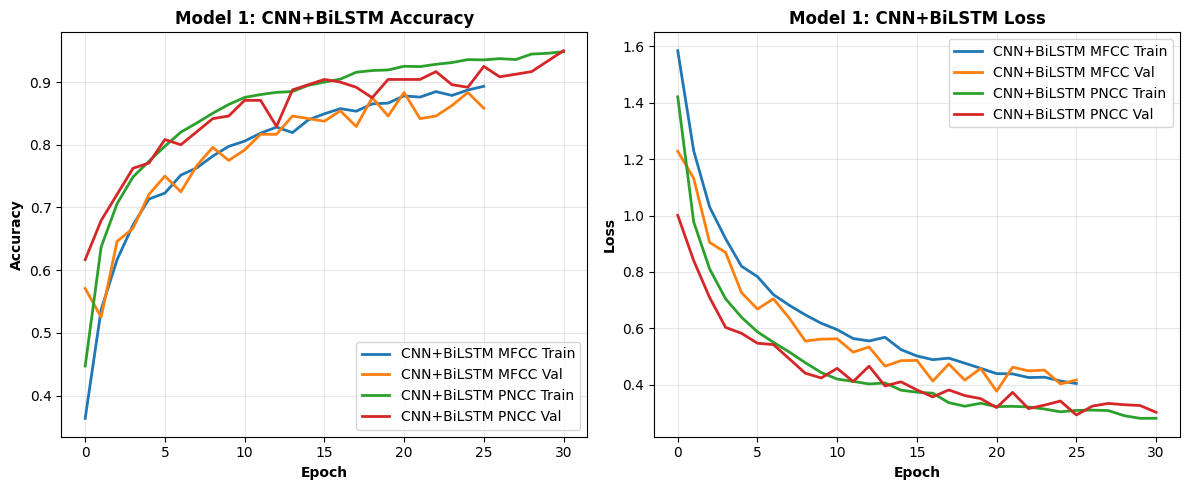

In [183]:
if history_model1_pncc is not None and history_model1_mfcc is not None:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(history_model1_mfcc.history['accuracy'], label='CNN+BiLSTM MFCC Train', linewidth=2)
    plt.plot(history_model1_mfcc.history['val_accuracy'], label='CNN+BiLSTM MFCC Val', linewidth=2)
    plt.plot(history_model1_pncc.history['accuracy'], label='CNN+BiLSTM PNCC Train', linewidth=2)
    plt.plot(history_model1_pncc.history['val_accuracy'], label='CNN+BiLSTM PNCC Val', linewidth=2)
    plt.title('Model 1: CNN+BiLSTM Accuracy', fontweight='bold', fontsize=12)
    plt.ylabel('Accuracy', fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    
    plt.subplot(1,2,2)
    plt.plot(history_model1_mfcc.history['loss'], label='CNN+BiLSTM MFCC Train', linewidth=2)
    plt.plot(history_model1_mfcc.history['val_loss'], label='CNN+BiLSTM MFCC Val', linewidth=2)
    plt.plot(history_model1_pncc.history['loss'], label='CNN+BiLSTM PNCC Train', linewidth=2)
    plt.plot(history_model1_pncc.history['val_loss'], label='CNN+BiLSTM PNCC Val', linewidth=2)
    plt.title('Model 1: CNN+BiLSTM Loss', fontweight='bold', fontsize=12)
    plt.ylabel('Loss', fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Training history not available for Model 1")

## Model 2: BiLSTM Only

In [184]:
model2_pncc_metrics = []
model2_mfcc_metrics = []

In [185]:
def build_bilstm_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(64)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy',
                  metrics=[CategoricalAccuracy(name='accuracy'), Precision(name='precision'), Recall(name='recall')])
    return model

### Model 2a: BiLSTM-only model for PNCC

In [186]:
print("Model 2a: BiLSTM on PNCC")
history_model2_pncc = None
test_fold_metrics_model2_pncc = []
best_model_2pncc = None
best_fold_2pncc = -1
best_f1_2pncc = -1
for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    # Ensure indices are integer numpy arrays
    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)

    X_train_fold = X_pncc_lstm[train_idx]
    X_val_fold = X_pncc_lstm[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    model = build_bilstm_model(X_train_fold.shape[1:], num_classes)
    
    history = model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, 
                       validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop], verbose=0)
    history_model2_pncc = history
    
    loss, acc, precision, recall = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    y_pred = model.predict(X_val_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_val_classes = np.argmax(y_val_fold, axis=1)
    f1 = f1_score(y_val_classes, y_pred_classes, average='weighted', zero_division=0)
    
    model2_pncc_metrics.append({'fold': fold_num + 1, 'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_score': f1})
    cv_results['fold'].append(fold_num + 1)
    cv_results['model'].append('Model 2 PNCC')
    cv_results['loss'].append(loss)
    cv_results['accuracy'].append(acc)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1_score'].append(f1)
    
    # Evaluate unseen test fold and use test F1 for model selection
    try:
        curr_test_idx = np.asarray(test_indices_list[fold_num], dtype=np.int64)
        X_test = X_pncc_lstm[curr_test_idx]
        y_test_local = y[curr_test_idx]
        loss_t, acc_t, prec_t, rec_t = model.evaluate(X_test, y_test_local, verbose=0)
        y_prob = model.predict(X_test, verbose=0)
        y_pred_test = np.argmax(y_prob, axis=1)
        y_true_test = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
        test_fold_metrics_model2_pncc.append({'fold': fold_num + 1, 'loss': loss_t, 'accuracy': acc_t, 'precision': prec_t, 'recall': rec_t, 'f1_score': f1_t})
        print(f"  Fold {fold_num + 1}: ValAcc={acc:.4f}, ValLoss={loss:.4f}, ValF1={f1:.4f} | TestAcc={acc_t:.4f}, TestLoss={loss_t:.4f}, TestF1={f1_t:.4f}")
        if f1_t > best_f1_2pncc:
            best_f1_2pncc = f1_t
            best_fold_2pncc = fold_num
            best_model_2pncc = model
    except Exception as e:
        print(f"    Test Fold {fold_num + 1} skipped: {e}")

# Save best model and evaluate on corresponding test set
if best_model_2pncc is not None:
    saved_models['Model 2 PNCC'] = best_model_2pncc
    try:
        best_model_2pncc.save('model2_pncc.keras')
    except Exception:
        pass
    
    # Evaluate best model on its corresponding fold's test set
    try:
        best_test_idx = np.asarray(test_indices_list[best_fold_2pncc], dtype=np.int64)
        X_test = X_pncc_lstm[best_test_idx]
        y_test_local = y[best_test_idx]
        loss_t, acc_t, prec_t, rec_t = best_model_2pncc.evaluate(X_test, y_test_local, verbose=0)
        y_prob = best_model_2pncc.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        test_results['model'].append('Model 2 PNCC')
        test_results['feature'].append('PNCC')
        test_results['fold'].append(best_fold_2pncc)
        test_results['loss'].append(loss_t)
        test_results['accuracy'].append(acc_t)
        test_results['precision'].append(prec_t)
        test_results['recall'].append(rec_t)
        test_results['f1_score'].append(f1_t)
        print(f"Test Model 2 PNCC (Best from Fold {best_fold_2pncc + 1}): Acc={acc_t:.4f}, Loss={loss_t:.4f}, Prec={prec_t:.4f}, Rec={rec_t:.4f}, F1={f1_t:.4f}")
    except Exception as e:
        print(f"Test evaluation skipped for Model 2 PNCC: {e}")

if test_fold_metrics_model2_pncc:
    best_test = max(test_fold_metrics_model2_pncc, key=lambda item: item['f1_score'])
    avg_test = {metric: float(np.mean([item[metric] for item in test_fold_metrics_model2_pncc])) for metric in ['loss', 'accuracy', 'precision', 'recall', 'f1_score']}
    print(f"Best Test Model 2 PNCC: Fold {best_test['fold']} | Acc={best_test['accuracy']:.4f}, Loss={best_test['loss']:.4f}, Prec={best_test['precision']:.4f}, Rec={best_test['recall']:.4f}, F1={best_test['f1_score']:.4f}")
    print(f"Avg Test Model 2 PNCC: Acc={avg_test['accuracy']:.4f}, Loss={avg_test['loss']:.4f}, Prec={avg_test['precision']:.4f}, Rec={avg_test['recall']:.4f}, F1={avg_test['f1_score']:.4f}")

Model 2a: BiLSTM on PNCC
  Fold 1: ValAcc=0.9336, ValLoss=0.1632, ValF1=0.9338 | TestAcc=0.8267, TestLoss=0.6897, TestF1=0.8233
  Fold 2: ValAcc=0.9461, ValLoss=0.1494, ValF1=0.9464 | TestAcc=0.7817, TestLoss=0.9483, TestF1=0.7733
  Fold 3: ValAcc=0.8739, ValLoss=0.2971, ValF1=0.8767 | TestAcc=0.7769, TestLoss=0.6641, TestF1=0.7733
  Fold 4: ValAcc=0.8870, ValLoss=0.3203, ValF1=0.8872 | TestAcc=0.7705, TestLoss=0.6919, TestF1=0.7664
  Fold 5: ValAcc=0.9250, ValLoss=0.2054, ValF1=0.9246 | TestAcc=0.8734, TestLoss=0.5161, TestF1=0.8741
Test Model 2 PNCC (Best from Fold 5): Acc=0.8734, Loss=0.5161, Prec=0.8734, Rec=0.8734, F1=0.8741
Best Test Model 2 PNCC: Fold 5 | Acc=0.8734, Loss=0.5161, Prec=0.8734, Rec=0.8734, F1=0.8741
Avg Test Model 2 PNCC: Acc=0.8058, Loss=0.7020, Prec=0.8088, Rec=0.8016, F1=0.8021


### Model 2b: BiLSTM-only model for MFCC

In [187]:
print("Model 2b: BiLSTM on MFCC")
history_model2_mfcc = None
test_fold_metrics_model2_mfcc = []
best_model_2mfcc = None
best_fold_2mfcc = -1
best_f1_2mfcc = -1
for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    # Ensure indices are integer numpy arrays
    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)

    X_train_fold = X_mfcc_lstm[train_idx]
    X_val_fold = X_mfcc_lstm[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    model = build_bilstm_model(X_train_fold.shape[1:], num_classes)
    
    history = model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, 
                       validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop], verbose=0)
    history_model2_mfcc = history
    
    loss, acc, precision, recall = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    y_pred = model.predict(X_val_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_val_classes = np.argmax(y_val_fold, axis=1)
    f1 = f1_score(y_val_classes, y_pred_classes, average='weighted', zero_division=0)
    
    model2_mfcc_metrics.append({'fold': fold_num + 1, 'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_score': f1})
    cv_results['fold'].append(fold_num + 1)
    cv_results['model'].append('Model 2 MFCC')
    cv_results['loss'].append(loss)
    cv_results['accuracy'].append(acc)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1_score'].append(f1)
    
    # Evaluate unseen test fold and use test F1 for model selection
    try:
        curr_test_idx = np.asarray(test_indices_list[fold_num], dtype=np.int64)
        X_test = X_mfcc_lstm[curr_test_idx]
        y_test_local = y[curr_test_idx]
        loss_t, acc_t, prec_t, rec_t = model.evaluate(X_test, y_test_local, verbose=0)
        y_prob = model.predict(X_test, verbose=0)
        y_pred_test = np.argmax(y_prob, axis=1)
        y_true_test = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
        test_fold_metrics_model2_mfcc.append({'fold': fold_num + 1, 'loss': loss_t, 'accuracy': acc_t, 'precision': prec_t, 'recall': rec_t, 'f1_score': f1_t})
        print(f"  Fold {fold_num + 1}: ValAcc={acc:.4f}, ValLoss={loss:.4f}, ValF1={f1:.4f} | TestAcc={acc_t:.4f}, TestLoss={loss_t:.4f}, TestF1={f1_t:.4f}")
        if f1_t > best_f1_2mfcc:
            best_f1_2mfcc = f1_t
            best_fold_2mfcc = fold_num
            best_model_2mfcc = model
    except Exception as e:
        print(f"    Test Fold {fold_num + 1} skipped: {e}")

# Save best model and evaluate on corresponding test set
if best_model_2mfcc is not None:
    saved_models['Model 2 MFCC'] = best_model_2mfcc
    try:
        best_model_2mfcc.save('model2_mfcc.keras')
    except Exception:
        pass
    
    try:
        best_test_idx = np.asarray(test_indices_list[best_fold_2mfcc], dtype=np.int64)
        X_test = X_mfcc_lstm[best_test_idx]
        y_test_local = y[best_test_idx]
        loss_t, acc_t, prec_t, rec_t = best_model_2mfcc.evaluate(X_test, y_test_local, verbose=0)
        y_prob = best_model_2mfcc.predict(X_test, verbose=0)
        y_pred_test = np.argmax(y_prob, axis=1)
        y_true_test = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
        test_results['model'].append('Model 2 MFCC')
        test_results['feature'].append('MFCC')
        test_results['fold'].append(best_fold_2mfcc)
        test_results['loss'].append(loss_t)
        test_results['accuracy'].append(acc_t)
        test_results['precision'].append(prec_t)
        test_results['recall'].append(rec_t)
        test_results['f1_score'].append(f1_t)
        print(f"Test Model 2 MFCC (Best from Fold {best_fold_2mfcc + 1}): Acc={acc_t:.4f}, Loss={loss_t:.4f}, Prec={prec_t:.4f}, Rec={rec_t:.4f}, F1={f1_t:.4f}")
    except Exception as e:
        print(f"Test evaluation skipped for Model 2 MFCC: {e}")

if test_fold_metrics_model2_mfcc:
    best_test = max(test_fold_metrics_model2_mfcc, key=lambda item: item['f1_score'])
    avg_test = {metric: float(np.mean([item[metric] for item in test_fold_metrics_model2_mfcc])) for metric in ['loss', 'accuracy', 'precision', 'recall', 'f1_score']}
    print(f"Best Test Model 2 MFCC: Fold {best_test['fold']} | Acc={best_test['accuracy']:.4f}, Loss={best_test['loss']:.4f}, Prec={best_test['precision']:.4f}, Rec={best_test['recall']:.4f}, F1={best_test['f1_score']:.4f}")
    print(f"Avg Test Model 2 MFCC: Acc={avg_test['accuracy']:.4f}, Loss={avg_test['loss']:.4f}, Prec={avg_test['precision']:.4f}, Rec={avg_test['recall']:.4f}, F1={avg_test['f1_score']:.4f}")

Model 2b: BiLSTM on MFCC
  Fold 1: ValAcc=0.9004, ValLoss=0.2134, ValF1=0.9013 | TestAcc=0.8400, TestLoss=0.4476, TestF1=0.8394
  Fold 2: ValAcc=0.8672, ValLoss=0.2896, ValF1=0.8672 | TestAcc=0.7729, TestLoss=0.6224, TestF1=0.7732
  Fold 3: ValAcc=0.9076, ValLoss=0.2378, ValF1=0.9075 | TestAcc=0.8645, TestLoss=0.5019, TestF1=0.8662
  Fold 4: ValAcc=0.9540, ValLoss=0.1754, ValF1=0.9538 | TestAcc=0.8402, TestLoss=0.4987, TestF1=0.8375
  Fold 5: ValAcc=0.9125, ValLoss=0.1935, ValF1=0.9127 | TestAcc=0.8481, TestLoss=0.4481, TestF1=0.8498
Test Model 2 MFCC (Best from Fold 3): Acc=0.8645, Loss=0.5019, Prec=0.8635, Rec=0.8566, F1=0.8662
Best Test Model 2 MFCC: Fold 3 | Acc=0.8645, Loss=0.5019, Prec=0.8635, Rec=0.8566, F1=0.8662
Avg Test Model 2 MFCC: Acc=0.8331, Loss=0.5038, Prec=0.8359, Rec=0.8289, F1=0.8332


### Model 2: Training History Visualization

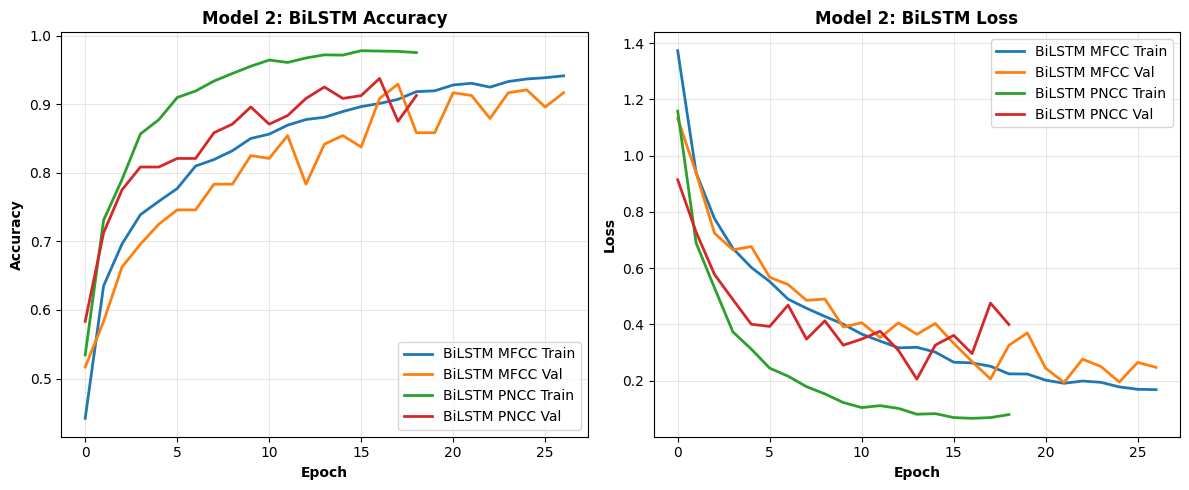

In [188]:
if history_model2_pncc is not None and history_model2_mfcc is not None:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(history_model2_mfcc.history['accuracy'], label='BiLSTM MFCC Train', linewidth=2)
    plt.plot(history_model2_mfcc.history['val_accuracy'], label='BiLSTM MFCC Val', linewidth=2)
    plt.plot(history_model2_pncc.history['accuracy'], label='BiLSTM PNCC Train', linewidth=2)
    plt.plot(history_model2_pncc.history['val_accuracy'], label='BiLSTM PNCC Val', linewidth=2)
    plt.title('Model 2: BiLSTM Accuracy', fontweight='bold', fontsize=12)
    plt.ylabel('Accuracy', fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    
    plt.subplot(1,2,2)
    plt.plot(history_model2_mfcc.history['loss'], label='BiLSTM MFCC Train', linewidth=2)
    plt.plot(history_model2_mfcc.history['val_loss'], label='BiLSTM MFCC Val', linewidth=2)
    plt.plot(history_model2_pncc.history['loss'], label='BiLSTM PNCC Train', linewidth=2)
    plt.plot(history_model2_pncc.history['val_loss'], label='BiLSTM PNCC Val', linewidth=2)
    plt.title('Model 2: BiLSTM Loss', fontweight='bold', fontsize=12)
    plt.ylabel('Loss', fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Training history not available for Model 2")

## Model 3: CNN Only

In [189]:
model3_pncc_metrics = []
model3_mfcc_metrics = []

In [190]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Conv1D(128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy',
                  metrics=[CategoricalAccuracy(name='accuracy'), Precision(name='precision'), Recall(name='recall')])
    return model

### Model 3a: CNN-only model for MFCC

In [191]:
print("Model 3a: CNN on PNCC")
history_model3_pncc = None
test_fold_metrics_model3_pncc = []
best_model_3pncc = None
best_fold_3pncc = -1
best_f1_3pncc = -1
for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    # Ensure indices are integer numpy arrays
    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)

    X_train_fold = X_pncc_lstm[train_idx]
    X_val_fold = X_pncc_lstm[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    model = build_cnn_model(X_train_fold.shape[1:], num_classes)
    
    history = model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, 
                       validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop], verbose=0)
    history_model3_pncc = history
    
    loss, acc, precision, recall = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    y_pred = model.predict(X_val_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_val_classes = np.argmax(y_val_fold, axis=1)
    f1 = f1_score(y_val_classes, y_pred_classes, average='weighted', zero_division=0)
    
    model3_pncc_metrics.append({'fold': fold_num + 1, 'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_score': f1})
    cv_results['fold'].append(fold_num + 1)
    cv_results['model'].append('Model 3 PNCC')
    cv_results['loss'].append(loss)
    cv_results['accuracy'].append(acc)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1_score'].append(f1)
    
    # Evaluate unseen test fold and use test F1 for model selection
    try:
        curr_test_idx = np.asarray(test_indices_list[fold_num], dtype=np.int64)
        X_test = X_pncc_lstm[curr_test_idx]
        y_test_local = y[curr_test_idx]
        loss_t, acc_t, prec_t, rec_t = model.evaluate(X_test, y_test_local, verbose=0)
        y_prob = model.predict(X_test, verbose=0)
        y_pred_test = np.argmax(y_prob, axis=1)
        y_true_test = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
        test_fold_metrics_model3_pncc.append({'fold': fold_num + 1, 'loss': loss_t, 'accuracy': acc_t, 'precision': prec_t, 'recall': rec_t, 'f1_score': f1_t})
        print(f"  Fold {fold_num + 1}: ValAcc={acc:.4f}, ValLoss={loss:.4f}, ValF1={f1:.4f} | TestAcc={acc_t:.4f}, TestLoss={loss_t:.4f}, TestF1={f1_t:.4f}")
        if f1_t > best_f1_3pncc:
            best_f1_3pncc = f1_t
            best_fold_3pncc = fold_num
            best_model_3pncc = model
    except Exception as e:
        print(f"    Test Fold {fold_num + 1} skipped: {e}")

# Save best model and evaluate on corresponding test set
if best_model_3pncc is not None:
    saved_models['Model 3 PNCC'] = best_model_3pncc
    try:
        best_model_3pncc.save('model3_pncc.keras')
    except Exception:
        pass
    
    # Evaluate best model on its corresponding fold's test set
    try:
        best_test_idx = np.asarray(test_indices_list[best_fold_3pncc], dtype=np.int64)
        X_test = X_pncc_lstm[best_test_idx]
        y_test_local = y[best_test_idx]
        loss_t, acc_t, prec_t, rec_t = best_model_3pncc.evaluate(X_test, y_test_local, verbose=0)
        y_prob = best_model_3pncc.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        test_results['model'].append('Model 3 PNCC')
        test_results['feature'].append('PNCC')
        test_results['fold'].append(best_fold_3pncc)
        test_results['loss'].append(loss_t)
        test_results['accuracy'].append(acc_t)
        test_results['precision'].append(prec_t)
        test_results['recall'].append(rec_t)
        test_results['f1_score'].append(f1_t)
        print(f"Test Model 3 PNCC (Best from Fold {best_fold_3pncc + 1}): Acc={acc_t:.4f}, Loss={loss_t:.4f}, Prec={prec_t:.4f}, Rec={rec_t:.4f}, F1={f1_t:.4f}")
    except Exception as e:
        print(f"Test evaluation skipped for Model 3 PNCC: {e}")

if test_fold_metrics_model3_pncc:
    best_test = max(test_fold_metrics_model3_pncc, key=lambda item: item['f1_score'])
    avg_test = {metric: float(np.mean([item[metric] for item in test_fold_metrics_model3_pncc])) for metric in ['loss', 'accuracy', 'precision', 'recall', 'f1_score']}
    print(f"Best Test Model 3 PNCC: Fold {best_test['fold']} | Acc={best_test['accuracy']:.4f}, Loss={best_test['loss']:.4f}, Prec={best_test['precision']:.4f}, Rec={best_test['recall']:.4f}, F1={best_test['f1_score']:.4f}")
    print(f"Avg Test Model 3 PNCC: Acc={avg_test['accuracy']:.4f}, Loss={avg_test['loss']:.4f}, Prec={avg_test['precision']:.4f}, Rec={avg_test['recall']:.4f}, F1={avg_test['f1_score']:.4f}")

Model 3a: CNN on PNCC


I0000 00:00:1780915638.271471     142 service.cc:152] XLA service 0x781227277a50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780915638.271522     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780915638.271528     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780915641.485301     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Fold 1: ValAcc=0.9627, ValLoss=0.1145, ValF1=0.9630 | TestAcc=0.8000, TestLoss=0.6471, TestF1=0.8014
  Fold 2: ValAcc=0.9461, ValLoss=0.1571, ValF1=0.9466 | TestAcc=0.7729, TestLoss=0.7272, TestF1=0.7688
  Fold 3: ValAcc=0.8824, ValLoss=0.3102, ValF1=0.8830 | TestAcc=0.8048, TestLoss=0.5947, TestF1=0.8003
  Fold 4: ValAcc=0.8828, ValLoss=0.2734, ValF1=0.8826 | TestAcc=0.8115, TestLoss=0.4701, TestF1=0.8122
  Fold 5: ValAcc=0.8792, ValLoss=0.2646, ValF1=0.8790 | TestAcc=0.8228, TestLoss=0.4959, TestF1=0.8255
Test Model 3 PNCC (Best from Fold 5): Acc=0.8228, Loss=0.4959, Prec=0.8348, Rec=0.8101, F1=0.8255
Best Test Model 3 PNCC: Fold 5 | Acc=0.8228, Loss=0.4959, Prec=0.8348, Rec=0.8101, F1=0.8255
Avg Test Model 3 PNCC: Acc=0.8024, Loss=0.5870, Prec=0.8143, Rec=0.7852, F1=0.8016


### Model 3b: CNN-only model for PNCC

In [192]:
print("Model 3b: CNN on MFCC")
history_model3_mfcc = None
test_fold_metrics_model3_mfcc = []
best_model_3mfcc = None
best_fold_3mfcc = -1
best_f1_3mfcc = -1
for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    # Ensure indices are integer numpy arrays before indexing
    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)
    X_train_fold = X_mfcc_lstm[train_idx]
    X_val_fold = X_mfcc_lstm[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    model = build_cnn_model(X_train_fold.shape[1:], num_classes)
    
    history = model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, 
                       validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop], verbose=0)
    history_model3_mfcc = history
    
    loss, acc, precision, recall = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    y_pred = model.predict(X_val_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_val_classes = np.argmax(y_val_fold, axis=1)
    f1 = f1_score(y_val_classes, y_pred_classes, average='weighted', zero_division=0)
    
    model3_mfcc_metrics.append({'fold': fold_num + 1, 'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_score': f1})
    cv_results['fold'].append(fold_num + 1)
    cv_results['model'].append('Model 3 MFCC')
    cv_results['loss'].append(loss)
    cv_results['accuracy'].append(acc)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1_score'].append(f1)
    
    # Evaluate unseen test fold and use test F1 for model selection
    try:
        curr_test_idx = np.asarray(test_indices_list[fold_num], dtype=np.int64)
        X_test = X_mfcc_lstm[curr_test_idx]
        y_test_local = y[curr_test_idx]
        loss_t, acc_t, prec_t, rec_t = model.evaluate(X_test, y_test_local, verbose=0)
        y_prob = model.predict(X_test, verbose=0)
        y_pred_test = np.argmax(y_prob, axis=1)
        y_true_test = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
        test_fold_metrics_model3_mfcc.append({'fold': fold_num + 1, 'loss': loss_t, 'accuracy': acc_t, 'precision': prec_t, 'recall': rec_t, 'f1_score': f1_t})
        print(f"  Fold {fold_num + 1}: ValAcc={acc:.4f}, ValLoss={loss:.4f}, ValF1={f1:.4f} | TestAcc={acc_t:.4f}, TestLoss={loss_t:.4f}, TestF1={f1_t:.4f}")
        if f1_t > best_f1_3mfcc:
            best_f1_3mfcc = f1_t
            best_fold_3mfcc = fold_num
            best_model_3mfcc = model
    except Exception as e:
        print(f"    Test Fold {fold_num + 1} skipped: {e}")

# Save best model and evaluate on corresponding test set
if best_model_3mfcc is not None:
    saved_models['Model 3 MFCC'] = best_model_3mfcc
    try:
        best_model_3mfcc.save('model3_mfcc.keras')
    except Exception:
        pass
    
    # Evaluate best model on its corresponding fold's test set
    try:
        best_test_idx = np.asarray(test_indices_list[best_fold_3mfcc], dtype=np.int64)
        X_test = X_mfcc_lstm[best_test_idx]
        y_test_local = y[best_test_idx]
        loss_t, acc_t, prec_t, rec_t = best_model_3mfcc.evaluate(X_test, y_test_local, verbose=0)
        y_prob = best_model_3mfcc.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        test_results['model'].append('Model 3 MFCC')
        test_results['feature'].append('MFCC')
        test_results['fold'].append(best_fold_3mfcc)
        test_results['loss'].append(loss_t)
        test_results['accuracy'].append(acc_t)
        test_results['precision'].append(prec_t)
        test_results['recall'].append(rec_t)
        test_results['f1_score'].append(f1_t)
        print(f"Test Model 3 MFCC (Best from Fold {best_fold_3mfcc + 1}): Acc={acc_t:.4f}, Loss={loss_t:.4f}, Prec={prec_t:.4f}, Rec={rec_t:.4f}, F1={f1_t:.4f}")
    except Exception as e:
        print(f"Test evaluation skipped for Model 3 MFCC: {e}")

if test_fold_metrics_model3_mfcc:
    best_test = max(test_fold_metrics_model3_mfcc, key=lambda item: item['f1_score'])
    avg_test = {metric: float(np.mean([item[metric] for item in test_fold_metrics_model3_mfcc])) for metric in ['loss', 'accuracy', 'precision', 'recall', 'f1_score']}
    print(f"Best Test Model 3 MFCC: Fold {best_test['fold']} | Acc={best_test['accuracy']:.4f}, Loss={best_test['loss']:.4f}, Prec={best_test['precision']:.4f}, Rec={best_test['recall']:.4f}, F1={best_test['f1_score']:.4f}")
    print(f"Avg Test Model 3 MFCC: Acc={avg_test['accuracy']:.4f}, Loss={avg_test['loss']:.4f}, Prec={avg_test['precision']:.4f}, Rec={avg_test['recall']:.4f}, F1={avg_test['f1_score']:.4f}")

Model 3b: CNN on MFCC
  Fold 1: ValAcc=0.9046, ValLoss=0.2217, ValF1=0.9044 | TestAcc=0.8000, TestLoss=0.5499, TestF1=0.8058
  Fold 2: ValAcc=0.9336, ValLoss=0.1881, ValF1=0.9337 | TestAcc=0.8210, TestLoss=0.7061, TestF1=0.8215
  Fold 3: ValAcc=0.9328, ValLoss=0.2600, ValF1=0.9343 | TestAcc=0.8725, TestLoss=0.3790, TestF1=0.8731
  Fold 4: ValAcc=0.8787, ValLoss=0.2805, ValF1=0.8779 | TestAcc=0.8197, TestLoss=0.3644, TestF1=0.8219
  Fold 5: ValAcc=0.9208, ValLoss=0.2010, ValF1=0.9212 | TestAcc=0.8523, TestLoss=0.4681, TestF1=0.8545
Test Model 3 MFCC (Best from Fold 3): Acc=0.8725, Loss=0.3790, Prec=0.8816, Rec=0.8606, F1=0.8731
Best Test Model 3 MFCC: Fold 3 | Acc=0.8725, Loss=0.3790, Prec=0.8816, Rec=0.8606, F1=0.8731
Avg Test Model 3 MFCC: Acc=0.8331, Loss=0.4935, Prec=0.8441, Rec=0.8142, F1=0.8354


### Model 3: Training History Visualization

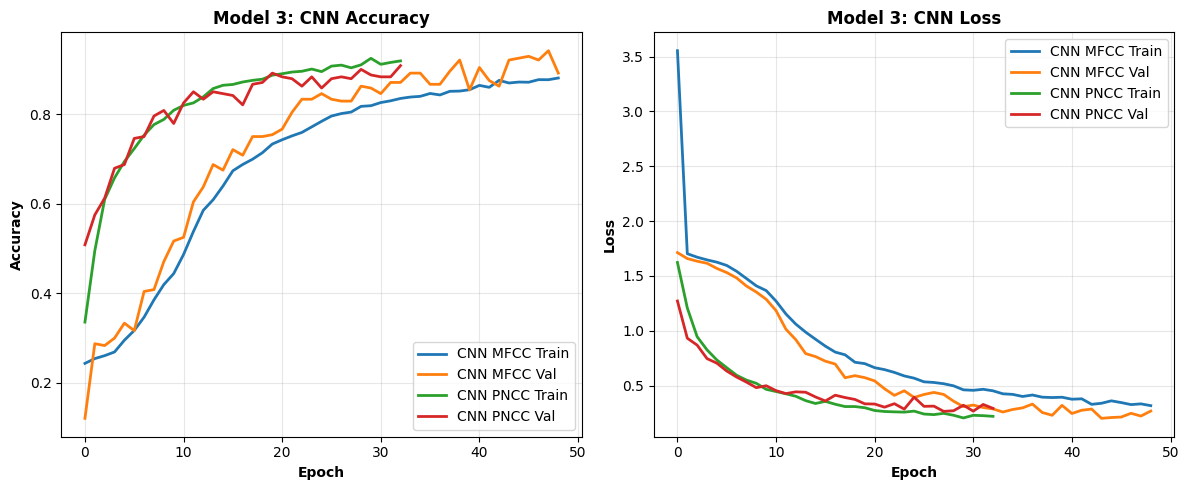

In [193]:
if history_model3_pncc is not None and history_model3_mfcc is not None:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(history_model3_mfcc.history['accuracy'], label='CNN MFCC Train', linewidth=2)
    plt.plot(history_model3_mfcc.history['val_accuracy'], label='CNN MFCC Val', linewidth=2)
    plt.plot(history_model3_pncc.history['accuracy'], label='CNN PNCC Train', linewidth=2)
    plt.plot(history_model3_pncc.history['val_accuracy'], label='CNN PNCC Val', linewidth=2)
    plt.title('Model 3: CNN Accuracy', fontweight='bold', fontsize=12)
    plt.ylabel('Accuracy', fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    
    plt.subplot(1,2,2)
    plt.plot(history_model3_mfcc.history['loss'], label='CNN MFCC Train', linewidth=2)
    plt.plot(history_model3_mfcc.history['val_loss'], label='CNN MFCC Val', linewidth=2)
    plt.plot(history_model3_pncc.history['loss'], label='CNN PNCC Train', linewidth=2)
    plt.plot(history_model3_pncc.history['val_loss'], label='CNN PNCC Val', linewidth=2)
    plt.title('Model 3: CNN Loss', fontweight='bold', fontsize=12)
    plt.ylabel('Loss', fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Training history not available for Model 3")

## Model 4: LSTM Only

In [194]:
model4_pncc_metrics = []
model4_mfcc_metrics = []

In [195]:
def build_lstm_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy',
                  metrics=[CategoricalAccuracy(name='accuracy'), Precision(name='precision'), Recall(name='recall')])
    return model

### Model 4a: LSTM-only model for PNCC

In [196]:
print("Model 4a: LSTM on PNCC")
history_model4_pncc = None
test_fold_metrics_model4_pncc = []
best_model_4pncc = None
best_fold_4pncc = -1
best_f1_4pncc = -1

for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    # Ensure indices are integer numpy arrays to avoid IndexError
    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)

    X_train_fold = X_pncc_lstm[train_idx]
    X_val_fold = X_pncc_lstm[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    model = build_lstm_model(X_train_fold.shape[1:], num_classes)
    
    history = model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, 
                       validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop], verbose=0)
    history_model4_pncc = history
    
    loss, acc, precision, recall = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    y_pred = model.predict(X_val_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_val_classes = np.argmax(y_val_fold, axis=1)
    f1 = f1_score(y_val_classes, y_pred_classes, average='weighted', zero_division=0)
    
    model4_pncc_metrics.append({'fold': fold_num + 1, 'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_score': f1})
    cv_results['fold'].append(fold_num + 1)
    cv_results['model'].append('Model 4 PNCC')
    cv_results['loss'].append(loss)
    cv_results['accuracy'].append(acc)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1_score'].append(f1)
    
    # Evaluate unseen test fold and use its F1 to select the best model
    try:
        curr_test_idx = np.asarray(test_indices_list[fold_num], dtype=np.int64)
        X_test = X_pncc_lstm[curr_test_idx]
        y_test_local = y[curr_test_idx]
        
        loss_t, acc_t, prec_t, rec_t = model.evaluate(X_test, y_test_local, verbose=0)
        y_prob = model.predict(X_test, verbose=0)
        y_pred_test = np.argmax(y_prob, axis=1)
        y_true_test = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
        
        test_fold_metrics_model4_pncc.append({'fold': fold_num + 1, 'loss': loss_t, 'accuracy': acc_t, 'precision': prec_t, 'recall': rec_t, 'f1_score': f1_t})
        print(f"  Fold {fold_num + 1}: ValAcc={acc:.4f}, ValLoss={loss:.4f}, ValF1={f1:.4f} | TestAcc={acc_t:.4f}, TestLoss={loss_t:.4f}, TestF1={f1_t:.4f}")
        
        # Use test F1 for selecting the best model (unseen speakers)
        if f1_t > best_f1_4pncc:
            best_f1_4pncc = f1_t
            best_fold_4pncc = fold_num
            best_model_4pncc = model
    except Exception as e:
        print(f"    Test Fold {fold_num + 1} skipped: {e}")

# Save best model and evaluate on corresponding test set
if best_model_4pncc is not None:
    saved_models['Model 4 PNCC'] = best_model_4pncc
    try:
        best_model_4pncc.save('model4_pncc.keras')
    except Exception:
        pass
    
    # Evaluate best model on its corresponding fold's test set
    try:
        best_test_idx = np.asarray(test_indices_list[best_fold_4pncc], dtype=np.int64)
        X_test = X_pncc_lstm[best_test_idx]
        y_test_local = y[best_test_idx]
        
        loss_t, acc_t, prec_t, rec_t = best_model_4pncc.evaluate(X_test, y_test_local, verbose=0)
        y_prob = best_model_4pncc.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        test_results['model'].append('Model 4 PNCC')
        test_results['feature'].append('PNCC')
        test_results['fold'].append(best_fold_4pncc)
        test_results['loss'].append(loss_t)
        test_results['accuracy'].append(acc_t)
        test_results['precision'].append(prec_t)
        test_results['recall'].append(rec_t)
        test_results['f1_score'].append(f1_t)
        print(f"Test Model 4 PNCC (Best from Fold {best_fold_4pncc + 1}): Acc={acc_t:.4f}, Loss={loss_t:.4f}, Prec={prec_t:.4f}, Rec={rec_t:.4f}, F1={f1_t:.4f}")
    except Exception as e:
        print(f"Test evaluation skipped for Model 4 PNCC: {e}")

if test_fold_metrics_model4_pncc:
    best_test = max(test_fold_metrics_model4_pncc, key=lambda item: item['f1_score'])
    avg_test = {metric: float(np.mean([item[metric] for item in test_fold_metrics_model4_pncc])) for metric in ['loss', 'accuracy', 'precision', 'recall', 'f1_score']}
    print(f"Best Test Model 4 PNCC: Fold {best_test['fold']} | Acc={best_test['accuracy']:.4f}, Loss={best_test['loss']:.4f}, Prec={best_test['precision']:.4f}, Rec={best_test['recall']:.4f}, F1={best_test['f1_score']:.4f}")
    print(f"Avg Test Model 4 PNCC: Acc={avg_test['accuracy']:.4f}, Loss={avg_test['loss']:.4f}, Prec={avg_test['precision']:.4f}, Rec={avg_test['recall']:.4f}, F1={avg_test['f1_score']:.4f}")

Model 4a: LSTM on PNCC
  Fold 1: ValAcc=0.8465, ValLoss=0.3882, ValF1=0.8477 | TestAcc=0.7644, TestLoss=0.6809, TestF1=0.7672
  Fold 2: ValAcc=0.8589, ValLoss=0.3272, ValF1=0.8578 | TestAcc=0.7205, TestLoss=0.9257, TestF1=0.7113
  Fold 3: ValAcc=0.8193, ValLoss=0.4432, ValF1=0.8195 | TestAcc=0.7410, TestLoss=0.8589, TestF1=0.7409
  Fold 4: ValAcc=0.8745, ValLoss=0.4044, ValF1=0.8734 | TestAcc=0.7992, TestLoss=0.7802, TestF1=0.7964
  Fold 5: ValAcc=0.8917, ValLoss=0.2858, ValF1=0.8912 | TestAcc=0.7848, TestLoss=0.8203, TestF1=0.7841
Test Model 4 PNCC (Best from Fold 4): Acc=0.7992, Loss=0.7802, Prec=0.7984, Rec=0.7951, F1=0.7964
Best Test Model 4 PNCC: Fold 4 | Acc=0.7992, Loss=0.7802, Prec=0.7984, Rec=0.7951, F1=0.7964
Avg Test Model 4 PNCC: Acc=0.7620, Loss=0.8132, Prec=0.7681, Rec=0.7521, F1=0.7600


### Model 4b: LSTM-only model for MFCC

In [197]:
print("Model 4b: LSTM on MFCC")
history_model4_mfcc = None
test_fold_metrics_model4_mfcc = []
best_model_4mfcc = None
best_fold_4mfcc = -1
best_f1_4mfcc = -1

for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    # Ensure indices are integer numpy arrays to avoid IndexError
    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)

    X_train_fold = X_mfcc_lstm[train_idx]
    X_val_fold = X_mfcc_lstm[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    model = build_lstm_model(X_train_fold.shape[1:], num_classes)
    
    history = model.fit(X_train_fold, y_train_fold, epochs=100, batch_size=32, 
                       validation_data=(X_val_fold, y_val_fold), callbacks=[early_stop], verbose=0)
    history_model4_mfcc = history
    
    loss, acc, precision, recall = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    y_pred = model.predict(X_val_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_val_classes = np.argmax(y_val_fold, axis=1)
    f1 = f1_score(y_val_classes, y_pred_classes, average='weighted', zero_division=0)
    
    model4_mfcc_metrics.append({'fold': fold_num + 1, 'loss': loss, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_score': f1})
    cv_results['fold'].append(fold_num + 1)
    cv_results['model'].append('Model 4 MFCC')
    cv_results['loss'].append(loss)
    cv_results['accuracy'].append(acc)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1_score'].append(f1)
    
    # Evaluate unseen test fold and use its F1 to select the best model
    try:
        curr_test_idx = np.asarray(test_indices_list[fold_num], dtype=np.int64)
        X_test = X_mfcc_lstm[curr_test_idx]
        y_test_local = y[curr_test_idx]
        
        loss_t, acc_t, prec_t, rec_t = model.evaluate(X_test, y_test_local, verbose=0)
        y_prob = model.predict(X_test, verbose=0)
        y_pred_test = np.argmax(y_prob, axis=1)
        y_true_test = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
        
        test_fold_metrics_model4_mfcc.append({'fold': fold_num + 1, 'loss': loss_t, 'accuracy': acc_t, 'precision': prec_t, 'recall': rec_t, 'f1_score': f1_t})
        print(f"  Fold {fold_num + 1}: ValAcc={acc:.4f}, ValLoss={loss:.4f}, ValF1={f1:.4f} | TestAcc={acc_t:.4f}, TestLoss={loss_t:.4f}, TestF1={f1_t:.4f}")
        
        # Use test F1 for selecting the best model (unseen speakers)
        if f1_t > best_f1_4mfcc:
            best_f1_4mfcc = f1_t
            best_fold_4mfcc = fold_num
            best_model_4mfcc = model
    except Exception as e:
        print(f"    Test Fold {fold_num + 1} skipped: {e}")

# Save best model and evaluate on corresponding test set
if best_model_4mfcc is not None:
    saved_models['Model 4 MFCC'] = best_model_4mfcc
    try:
        best_model_4mfcc.save('model4_mfcc.keras')
    except Exception:
        pass
    
    # Evaluate best model on its corresponding fold's test set
    try:
        best_test_idx = np.asarray(test_indices_list[best_fold_4mfcc], dtype=np.int64)
        X_test = X_mfcc_lstm[best_test_idx]
        y_test_local = y[best_test_idx]
        
        loss_t, acc_t, prec_t, rec_t = best_model_4mfcc.evaluate(X_test, y_test_local, verbose=0)
        y_prob = best_model_4mfcc.predict(X_test, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_test_local, axis=1)
        f1_t = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        test_results['model'].append('Model 4 MFCC')
        test_results['feature'].append('MFCC')
        test_results['fold'].append(best_fold_4mfcc)
        test_results['loss'].append(loss_t)
        test_results['accuracy'].append(acc_t)
        test_results['precision'].append(prec_t)
        test_results['recall'].append(rec_t)
        test_results['f1_score'].append(f1_t)
        print(f"Test Model 4 MFCC (Best from Fold {best_fold_4mfcc + 1}): Acc={acc_t:.4f}, Loss={loss_t:.4f}, Prec={prec_t:.4f}, Rec={rec_t:.4f}, F1={f1_t:.4f}")
    except Exception as e:
        print(f"Test evaluation skipped for Model 4 MFCC: {e}")

if test_fold_metrics_model4_mfcc:
    best_test = max(test_fold_metrics_model4_mfcc, key=lambda item: item['f1_score'])
    avg_test = {metric: float(np.mean([item[metric] for item in test_fold_metrics_model4_mfcc])) for metric in ['loss', 'accuracy', 'precision', 'recall', 'f1_score']}
    print(f"Best Test Model 4 MFCC: Fold {best_test['fold']} | Acc={best_test['accuracy']:.4f}, Loss={best_test['loss']:.4f}, Prec={best_test['precision']:.4f}, Rec={best_test['recall']:.4f}, F1={best_test['f1_score']:.4f}")
    print(f"Avg Test Model 4 MFCC: Acc={avg_test['accuracy']:.4f}, Loss={avg_test['loss']:.4f}, Prec={avg_test['precision']:.4f}, Rec={avg_test['recall']:.4f}, F1={avg_test['f1_score']:.4f}")

Model 4b: LSTM on MFCC
  Fold 1: ValAcc=0.8174, ValLoss=0.3809, ValF1=0.8197 | TestAcc=0.7733, TestLoss=0.6203, TestF1=0.7786
  Fold 2: ValAcc=0.3817, ValLoss=1.3755, ValF1=0.3796 | TestAcc=0.3144, TestLoss=1.4653, TestF1=0.3139
  Fold 3: ValAcc=0.8866, ValLoss=0.3137, ValF1=0.8880 | TestAcc=0.8167, TestLoss=0.5904, TestF1=0.8176
  Fold 4: ValAcc=0.8159, ValLoss=0.4414, ValF1=0.8159 | TestAcc=0.7008, TestLoss=0.7678, TestF1=0.7054
  Fold 5: ValAcc=0.8625, ValLoss=0.3223, ValF1=0.8638 | TestAcc=0.7595, TestLoss=0.6760, TestF1=0.7570
Test Model 4 MFCC (Best from Fold 3): Acc=0.8167, Loss=0.5904, Prec=0.8320, Rec=0.8088, F1=0.8176
Best Test Model 4 MFCC: Fold 3 | Acc=0.8167, Loss=0.5904, Prec=0.8320, Rec=0.8088, F1=0.8176
Avg Test Model 4 MFCC: Acc=0.6730, Loss=0.8240, Prec=0.7579, Rec=0.6122, F1=0.6745


In [198]:
# Summarize test results collected from each saved model
import pandas as pd

if any(test_results.values()):
    test_df = pd.DataFrame(test_results)
    if not test_df.empty:
        print("TEST RESULTS (per model):")
        print(test_df.to_string(index=False))
        # Save to CSV for quick inspection
        try:
            test_df.to_csv('test_results_summary.csv', index=False)
            print('\nSaved test results to test_results_summary.csv')
        except Exception:
            pass
    else:
        print("No test results collected. Run the training cells first.")
else:
    print("No test results collected. Run the training cells first.")

TEST RESULTS (per model):
       model feature  fold     loss  accuracy  precision   recall  f1_score
Model 1 PNCC    PNCC     4 0.518717  0.873418   0.872881 0.869198  0.873533
Model 1 MFCC    MFCC     0 0.452582  0.857778   0.877273 0.857778  0.858180
Model 2 PNCC    PNCC     4 0.516073  0.873418   0.873418 0.873418  0.874119
Model 2 MFCC    MFCC     2 0.501899  0.864542   0.863454 0.856574  0.866164
Model 3 PNCC    PNCC     4 0.495913  0.822785   0.834783 0.810127  0.825543
Model 3 MFCC    MFCC     2 0.378997  0.872510   0.881633 0.860558  0.873095
Model 4 PNCC    PNCC     3 0.780247  0.799180   0.798354 0.795082  0.796400
Model 4 MFCC    MFCC     2 0.590433  0.816733   0.831967 0.808765  0.817632

Saved test results to test_results_summary.csv


### Model 4: Training History Visualization

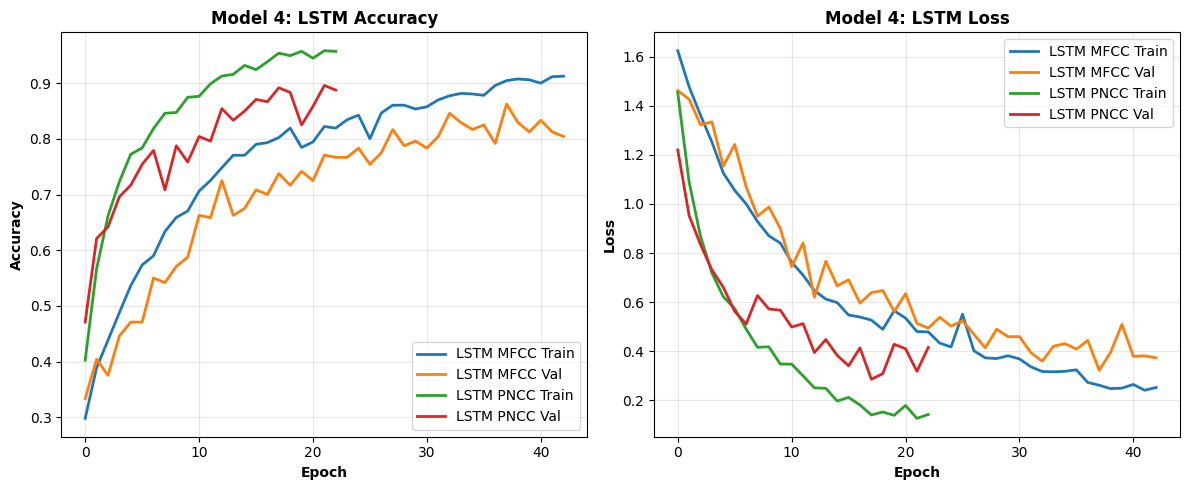

In [200]:
if history_model4_pncc is not None and history_model4_mfcc is not None:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(history_model4_mfcc.history['accuracy'], label='LSTM MFCC Train', linewidth=2)
    plt.plot(history_model4_mfcc.history['val_accuracy'], label='LSTM MFCC Val', linewidth=2)
    plt.plot(history_model4_pncc.history['accuracy'], label='LSTM PNCC Train', linewidth=2)
    plt.plot(history_model4_pncc.history['val_accuracy'], label='LSTM PNCC Val', linewidth=2)
    plt.title('Model 4: LSTM Accuracy', fontweight='bold', fontsize=12)
    plt.ylabel('Accuracy', fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    
    plt.subplot(1,2,2)
    plt.plot(history_model4_mfcc.history['loss'], label='LSTM MFCC Train', linewidth=2)
    plt.plot(history_model4_mfcc.history['val_loss'], label='LSTM MFCC Val', linewidth=2)
    plt.plot(history_model4_pncc.history['loss'], label='LSTM PNCC Train', linewidth=2)
    plt.plot(history_model4_pncc.history['val_loss'], label='LSTM PNCC Val', linewidth=2)
    plt.title('Model 4: LSTM Loss', fontweight='bold', fontsize=12)
    plt.ylabel('Loss', fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Training history not available for Model 4")

# Evaluasi Model

## Summary

Create comprehensive results DataFrame

Calculate and display per-model averages

In [201]:
print("\n" + "="*100)
print("MODEL PERFORMANCE SUMMARY (TEST SET RESULTS)")
print("="*100)

models = test_df['model'].unique()
summary_data = []

for model_name in sorted(models):
    model_data = test_df[test_df['model'] == model_name]
    summary_data.append({
        'Model': model_name,
        'Feature': model_data['feature'].iloc[0],
        'Accuracy': f"{model_data['accuracy'].iloc[0]:.4f}",
        'Precision': f"{model_data['precision'].iloc[0]:.4f}",
        'Recall': f"{model_data['recall'].iloc[0]:.4f}",
        'F1 Score': f"{model_data['f1_score'].iloc[0]:.4f}",
        'Loss': f"{model_data['loss'].iloc[0]:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*100)


MODEL PERFORMANCE SUMMARY (TEST SET RESULTS)
       Model Feature Accuracy Precision Recall F1 Score   Loss
Model 1 MFCC    MFCC   0.8578    0.8773 0.8578   0.8582 0.4526
Model 1 PNCC    PNCC   0.8734    0.8729 0.8692   0.8735 0.5187
Model 2 MFCC    MFCC   0.8645    0.8635 0.8566   0.8662 0.5019
Model 2 PNCC    PNCC   0.8734    0.8734 0.8734   0.8741 0.5161
Model 3 MFCC    MFCC   0.8725    0.8816 0.8606   0.8731 0.3790
Model 3 PNCC    PNCC   0.8228    0.8348 0.8101   0.8255 0.4959
Model 4 MFCC    MFCC   0.8167    0.8320 0.8088   0.8176 0.5904
Model 4 PNCC    PNCC   0.7992    0.7984 0.7951   0.7964 0.7802


Find best performers for each metric

In [202]:
print("\nBEST PERFORMING MODELS BY METRIC (TEST SET):")
print("-"*100)

metrics_summary = []
for model_name in sorted(models):
    model_data = test_df[test_df['model'] == model_name]
    metrics_summary.append({
        'Model': model_name,
        'Accuracy': model_data['accuracy'].iloc[0],
        'Precision': model_data['precision'].iloc[0],
        'Recall': model_data['recall'].iloc[0],
        'F1 Score': model_data['f1_score'].iloc[0],
        'Loss': model_data['loss'].iloc[0]
    })

metrics_df = pd.DataFrame(metrics_summary)

print(f"\n  Highest Accuracy:   {metrics_df.loc[metrics_df['Accuracy'].idxmax(), 'Model']:20} → {metrics_df['Accuracy'].max():.4f}")
print(f"  Highest Precision:  {metrics_df.loc[metrics_df['Precision'].idxmax(), 'Model']:20} → {metrics_df['Precision'].max():.4f}")
print(f"  Highest Recall:     {metrics_df.loc[metrics_df['Recall'].idxmax(), 'Model']:20} → {metrics_df['Recall'].max():.4f}")
print(f"  Highest F1 Score:   {metrics_df.loc[metrics_df['F1 Score'].idxmax(), 'Model']:20} → {metrics_df['F1 Score'].max():.4f}")
print(f"  Lowest Loss:        {metrics_df.loc[metrics_df['Loss'].idxmin(), 'Model']:20} → {metrics_df['Loss'].min():.4f}")
print("-"*100)


BEST PERFORMING MODELS BY METRIC (TEST SET):
----------------------------------------------------------------------------------------------------

  Highest Accuracy:   Model 1 PNCC         → 0.8734
  Highest Precision:  Model 3 MFCC         → 0.8816
  Highest Recall:     Model 2 PNCC         → 0.8734
  Highest F1 Score:   Model 2 PNCC         → 0.8741
  Lowest Loss:        Model 3 MFCC         → 0.3790
----------------------------------------------------------------------------------------------------


Compare feature types

In [203]:
print("\nFEATURE TYPE COMPARISON (TEST SET):")
print("-"*100)
feature_comparison = []
for feature in ['PNCC', 'MFCC']:
    feature_models = test_df[test_df['feature'] == feature]
    if len(feature_models) > 0:
        feature_comparison.append({
            'Feature': feature,
            'Avg Accuracy': f"{feature_models['accuracy'].mean():.4f}",
            'Avg Precision': f"{feature_models['precision'].mean():.4f}",
            'Avg Recall': f"{feature_models['recall'].mean():.4f}",
            'Avg F1 Score': f"{feature_models['f1_score'].mean():.4f}",
            'Avg Loss': f"{feature_models['loss'].mean():.4f}"
        })

feature_df = pd.DataFrame(feature_comparison)
print(feature_df.to_string(index=False))
print("-"*100)


FEATURE TYPE COMPARISON (TEST SET):
----------------------------------------------------------------------------------------------------
Feature Avg Accuracy Avg Precision Avg Recall Avg F1 Score Avg Loss
   PNCC       0.8422        0.8449     0.8370       0.8424   0.5777
   MFCC       0.8529        0.8636     0.8459       0.8538   0.4810
----------------------------------------------------------------------------------------------------


In [204]:
# Build test_df from test_results for test-only metrics summary
import pandas as pd

if test_results['model']:  # If test_results has data
    test_df = pd.DataFrame(test_results)
    
    print("\n" + "="*100)
    print("TEST SET METRICS SUMMARY (8 Models Evaluated on Global Test Set)")
    print("="*100)
    
    # Display all test results
    print("\nAll Test Results:")
    print(test_df[['model', 'feature', 'accuracy', 'precision', 'recall', 'f1_score', 'loss']].to_string(index=False))
    
    # Per-model averages (since each model is tested once)
    print("\n" + "-"*100)
    print("Test Performance by Model:")
    print("-"*100)
    
    test_summary = test_df.groupby('model')[['accuracy', 'precision', 'recall', 'f1_score', 'loss']].agg(['mean', 'std'])
    print(test_summary)
    
    # Best performers by metric
    print("\n" + "-"*100)
    print("BEST PERFORMING MODELS (on Test Set):")
    print("-"*100)
    print(f"  Highest Accuracy:   {test_df.loc[test_df['accuracy'].idxmax(), 'model']:20} → {test_df['accuracy'].max():.4f}")
    print(f"  Highest Precision:  {test_df.loc[test_df['precision'].idxmax(), 'model']:20} → {test_df['precision'].max():.4f}")
    print(f"  Highest Recall:     {test_df.loc[test_df['recall'].idxmax(), 'model']:20} → {test_df['recall'].max():.4f}")
    print(f"  Highest F1 Score:   {test_df.loc[test_df['f1_score'].idxmax(), 'model']:20} → {test_df['f1_score'].max():.4f}")
    print(f"  Lowest Loss:        {test_df.loc[test_df['loss'].idxmin(), 'model']:20} → {test_df['loss'].min():.4f}")
    print("="*100)
else:
    print("test_results is empty. Run model training cells first.")


TEST SET METRICS SUMMARY (8 Models Evaluated on Global Test Set)

All Test Results:
       model feature  accuracy  precision   recall  f1_score     loss
Model 1 PNCC    PNCC  0.873418   0.872881 0.869198  0.873533 0.518717
Model 1 MFCC    MFCC  0.857778   0.877273 0.857778  0.858180 0.452582
Model 2 PNCC    PNCC  0.873418   0.873418 0.873418  0.874119 0.516073
Model 2 MFCC    MFCC  0.864542   0.863454 0.856574  0.866164 0.501899
Model 3 PNCC    PNCC  0.822785   0.834783 0.810127  0.825543 0.495913
Model 3 MFCC    MFCC  0.872510   0.881633 0.860558  0.873095 0.378997
Model 4 PNCC    PNCC  0.799180   0.798354 0.795082  0.796400 0.780247
Model 4 MFCC    MFCC  0.816733   0.831967 0.808765  0.817632 0.590433

----------------------------------------------------------------------------------------------------
Test Performance by Model:
----------------------------------------------------------------------------------------------------
              accuracy     precision        recall     

Compare model architectures

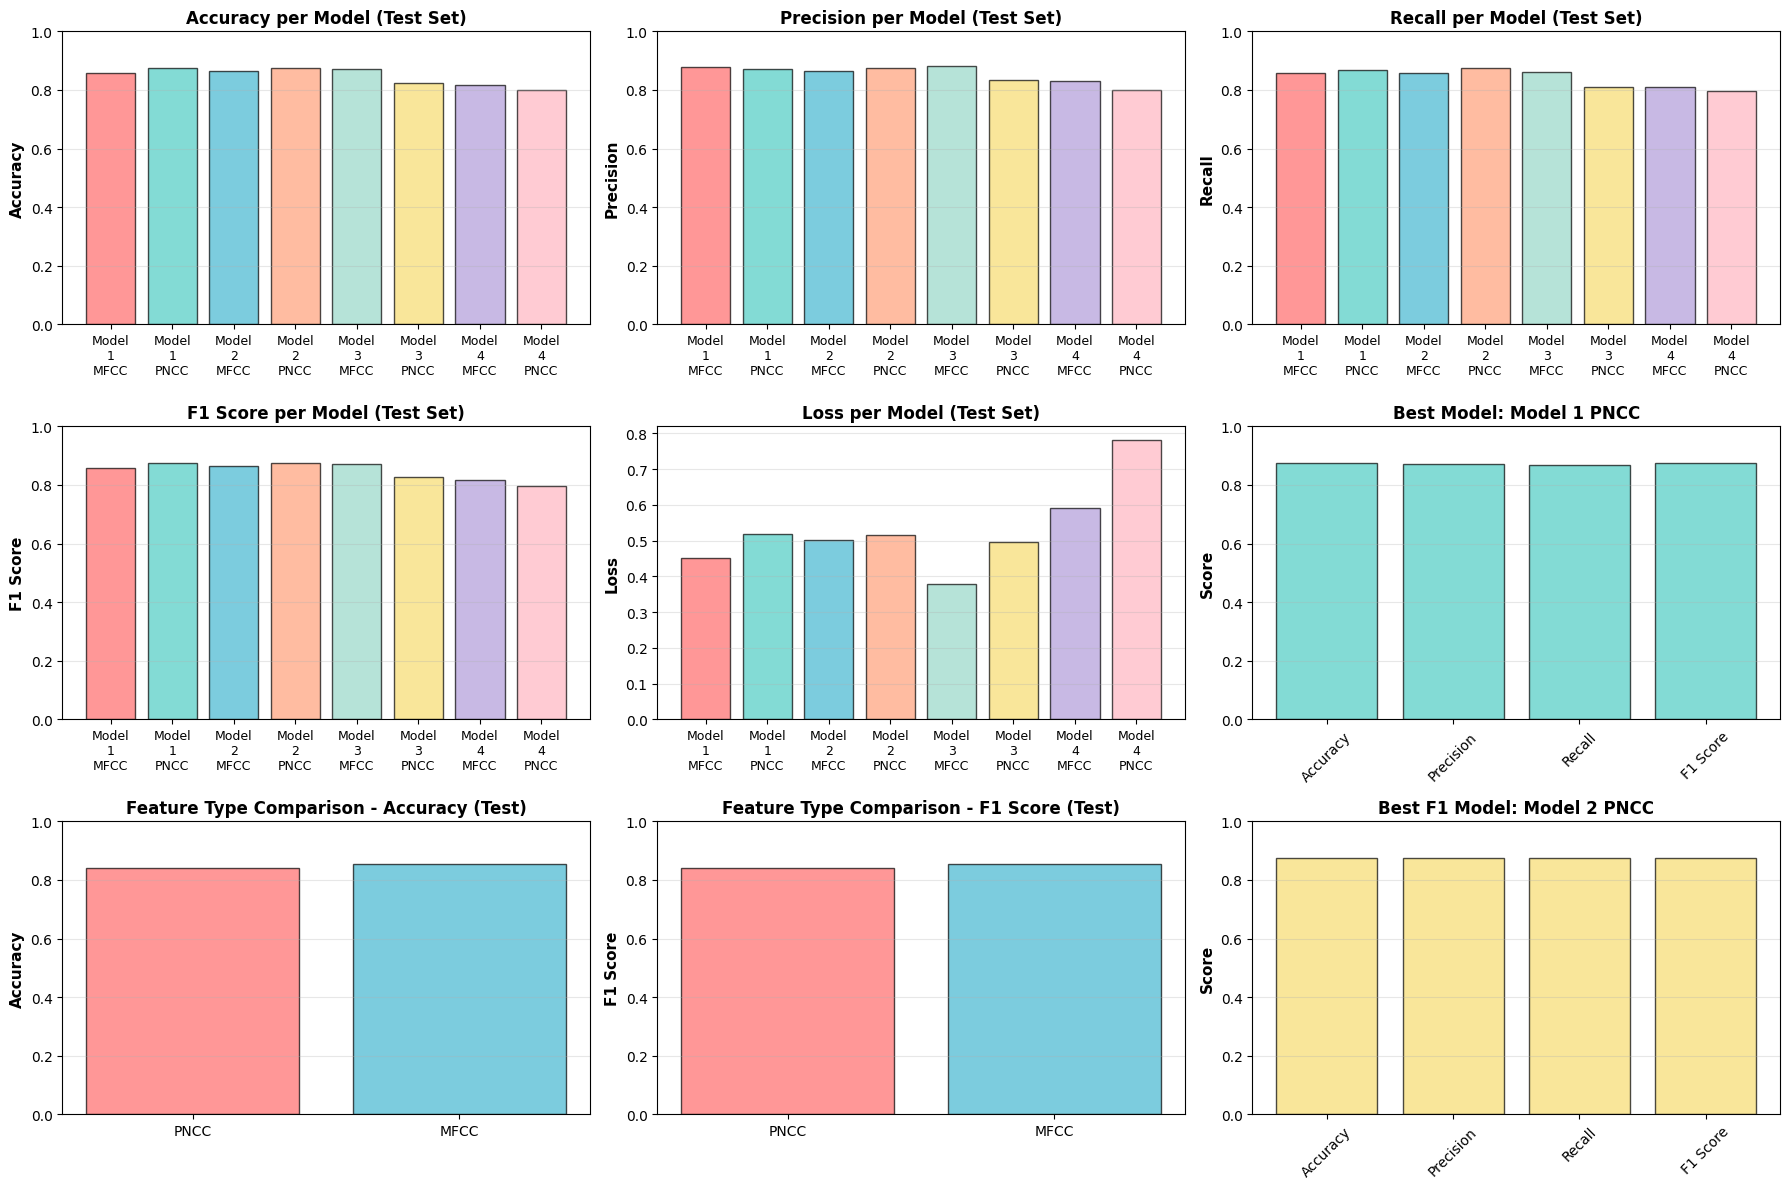


Test Set Visualization completed.
Best performing model (Accuracy): Model 1 PNCC with Accuracy = 0.8734
Best performing model (F1 Score): Model 2 PNCC with F1 Score = 0.8741


In [205]:
# Visualize test set results
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

models_list = sorted(test_df['model'].unique())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#B19CD9', '#FFB6C1']

# Plot 1: Accuracy by Model
ax = axes[0, 0]
accuracies = [test_df[test_df['model'] == m]['accuracy'].iloc[0] for m in models_list]
bars = ax.bar(range(len(models_list)), accuracies, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Accuracy per Model (Test Set)', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(models_list)))
ax.set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=9)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Plot 2: Precision by Model
ax = axes[0, 1]
precisions = [test_df[test_df['model'] == m]['precision'].iloc[0] for m in models_list]
ax.bar(range(len(models_list)), precisions, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax.set_title('Precision per Model (Test Set)', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(models_list)))
ax.set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=9)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Plot 3: Recall by Model
ax = axes[0, 2]
recalls = [test_df[test_df['model'] == m]['recall'].iloc[0] for m in models_list]
ax.bar(range(len(models_list)), recalls, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax.set_title('Recall per Model (Test Set)', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(models_list)))
ax.set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=9)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Plot 4: F1 Score by Model
ax = axes[1, 0]
f1_scores = [test_df[test_df['model'] == m]['f1_score'].iloc[0] for m in models_list]
ax.bar(range(len(models_list)), f1_scores, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax.set_title('F1 Score per Model (Test Set)', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(models_list)))
ax.set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=9)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Plot 5: Loss by Model
ax = axes[1, 1]
losses = [test_df[test_df['model'] == m]['loss'].iloc[0] for m in models_list]
ax.bar(range(len(models_list)), losses, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax.set_title('Loss per Model (Test Set)', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(models_list)))
ax.set_xticklabels([m.replace(' ', '\n') for m in models_list], fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Plot 6: All Metrics Comparison for Best Model
ax = axes[1, 2]
best_model_idx = np.argmax(accuracies)
best_model_name = models_list[best_model_idx]
best_model_data = test_df[test_df['model'] == best_model_name].iloc[0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_means = [best_model_data['accuracy'], best_model_data['precision'], best_model_data['recall'], best_model_data['f1_score']]
ax.bar(metrics_names, metrics_means, color='#4ECDC4', edgecolor='black', alpha=0.7)
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title(f'Best Model: {best_model_name}', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Plot 7: Feature Type Comparison - Accuracy
ax = axes[2, 0]
pncc_data = test_df[test_df['feature'] == 'PNCC']
mfcc_data = test_df[test_df['feature'] == 'MFCC']
feature_names = ['PNCC', 'MFCC']
feature_accuracy = [pncc_data['accuracy'].mean(), mfcc_data['accuracy'].mean()]
ax.bar(feature_names, feature_accuracy, color=['#FF6B6B', '#45B7D1'], edgecolor='black', alpha=0.7)
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Feature Type Comparison - Accuracy (Test)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Plot 8: Feature Type Comparison - F1 Score
ax = axes[2, 1]
feature_f1 = [pncc_data['f1_score'].mean(), mfcc_data['f1_score'].mean()]
ax.bar(feature_names, feature_f1, color=['#FF6B6B', '#45B7D1'], edgecolor='black', alpha=0.7)
ax.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax.set_title('Feature Type Comparison - F1 Score (Test)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Plot 9: Best Model by F1 Score
ax = axes[2, 2]
best_f1_idx = np.argmax(f1_scores)
best_f1_model = models_list[best_f1_idx]
best_f1_data = test_df[test_df['model'] == best_f1_model].iloc[0]
f1_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
f1_metrics_means = [best_f1_data['accuracy'], best_f1_data['precision'], best_f1_data['recall'], best_f1_data['f1_score']]
ax.bar(f1_metrics, f1_metrics_means, color='#F7DC6F', edgecolor='black', alpha=0.7)
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title(f'Best F1 Model: {best_f1_model}', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nTest Set Visualization completed.")
print(f"Best performing model (Accuracy): {best_model_name} with Accuracy = {accuracies[best_model_idx]:.4f}")
print(f"Best performing model (F1 Score): {best_f1_model} with F1 Score = {f1_scores[best_f1_idx]:.4f}")

## Confusion Matrix

In [206]:
# Ensure required imports are available
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get class names
class_names = list(labels.keys())
num_classes = len(class_names)

# Initialize storage for aggregate confusion matrices
aggregate_cm_all_models = {}
for model in sorted(test_df['model'].unique()):
    aggregate_cm_all_models[model] = np.zeros((num_classes, num_classes), dtype=int)

# Create mapping of model names to their best fold from test_results
model_fold_mapping = {}
for idx, row in test_df.iterrows():
    model_fold_mapping[row['model']] = int(row['fold'])

# Build confusion matrices from PER-FOLD TEST SET predictions
print("Building confusion matrices from PER-FOLD TEST SET predictions...\n")

for model_name in sorted(test_df['model'].unique()):
    try:
        # Get the saved model
        if model_name in saved_models:
            model = saved_models[model_name]
            best_fold = model_fold_mapping[model_name]
            
            # Determine which test data to use based on model name and its corresponding fold
            if 'PNCC' in model_name:
                X_test = X_pncc_lstm[test_indices_list[best_fold]]
            else:
                X_test = X_mfcc_lstm[test_indices_list[best_fold]]
            
            y_test = y[test_indices_list[best_fold]]
            
            # Get predictions
            y_pred_probs = model.predict(X_test, verbose=0)
            y_pred_classes = np.argmax(y_pred_probs, axis=1)
            y_true_classes = np.argmax(y_test, axis=1)
            
            # Compute confusion matrix for fold's test set
            cm_test = confusion_matrix(y_true_classes, y_pred_classes, labels=range(num_classes))
            aggregate_cm_all_models[model_name] = cm_test
            
            print(f"✓ {model_name} (Fold {best_fold + 1}): {cm_test.sum()} test predictions")
        else:
            print(f"✗ {model_name}: Model not found in saved_models")
    except Exception as e:
        print(f"✗ {model_name}: Error building confusion matrix - {e}")

# Verify confusion matrices were populated
print("\n" + "="*60)
print("Per-Fold Test Set Confusion Matrix Summary:")
print("="*60)
for model_name in sorted(test_df['model'].unique()):
    cm_sum = aggregate_cm_all_models[model_name].sum()
    status = "✓" if cm_sum > 0 else "✗"
    best_fold = model_fold_mapping.get(model_name, -1)
    print(f"{status} {model_name} (Fold {best_fold + 1}): {int(cm_sum)} total test predictions")

print("\nConfusion matrices built from PER-FOLD TEST SET predictions for each model.")

Building confusion matrices from PER-FOLD TEST SET predictions...

✓ Model 1 MFCC (Fold 1): 225 test predictions
✓ Model 1 PNCC (Fold 5): 237 test predictions
✓ Model 2 MFCC (Fold 3): 251 test predictions
✓ Model 2 PNCC (Fold 5): 237 test predictions
✓ Model 3 MFCC (Fold 3): 251 test predictions
✓ Model 3 PNCC (Fold 5): 237 test predictions
✓ Model 4 MFCC (Fold 3): 251 test predictions
✓ Model 4 PNCC (Fold 4): 244 test predictions

Per-Fold Test Set Confusion Matrix Summary:
✓ Model 1 MFCC (Fold 1): 225 total test predictions
✓ Model 1 PNCC (Fold 5): 237 total test predictions
✓ Model 2 MFCC (Fold 3): 251 total test predictions
✓ Model 2 PNCC (Fold 5): 237 total test predictions
✓ Model 3 MFCC (Fold 3): 251 total test predictions
✓ Model 3 PNCC (Fold 5): 237 total test predictions
✓ Model 4 MFCC (Fold 3): 251 total test predictions
✓ Model 4 PNCC (Fold 4): 244 total test predictions

Confusion matrices built from PER-FOLD TEST SET predictions for each model.


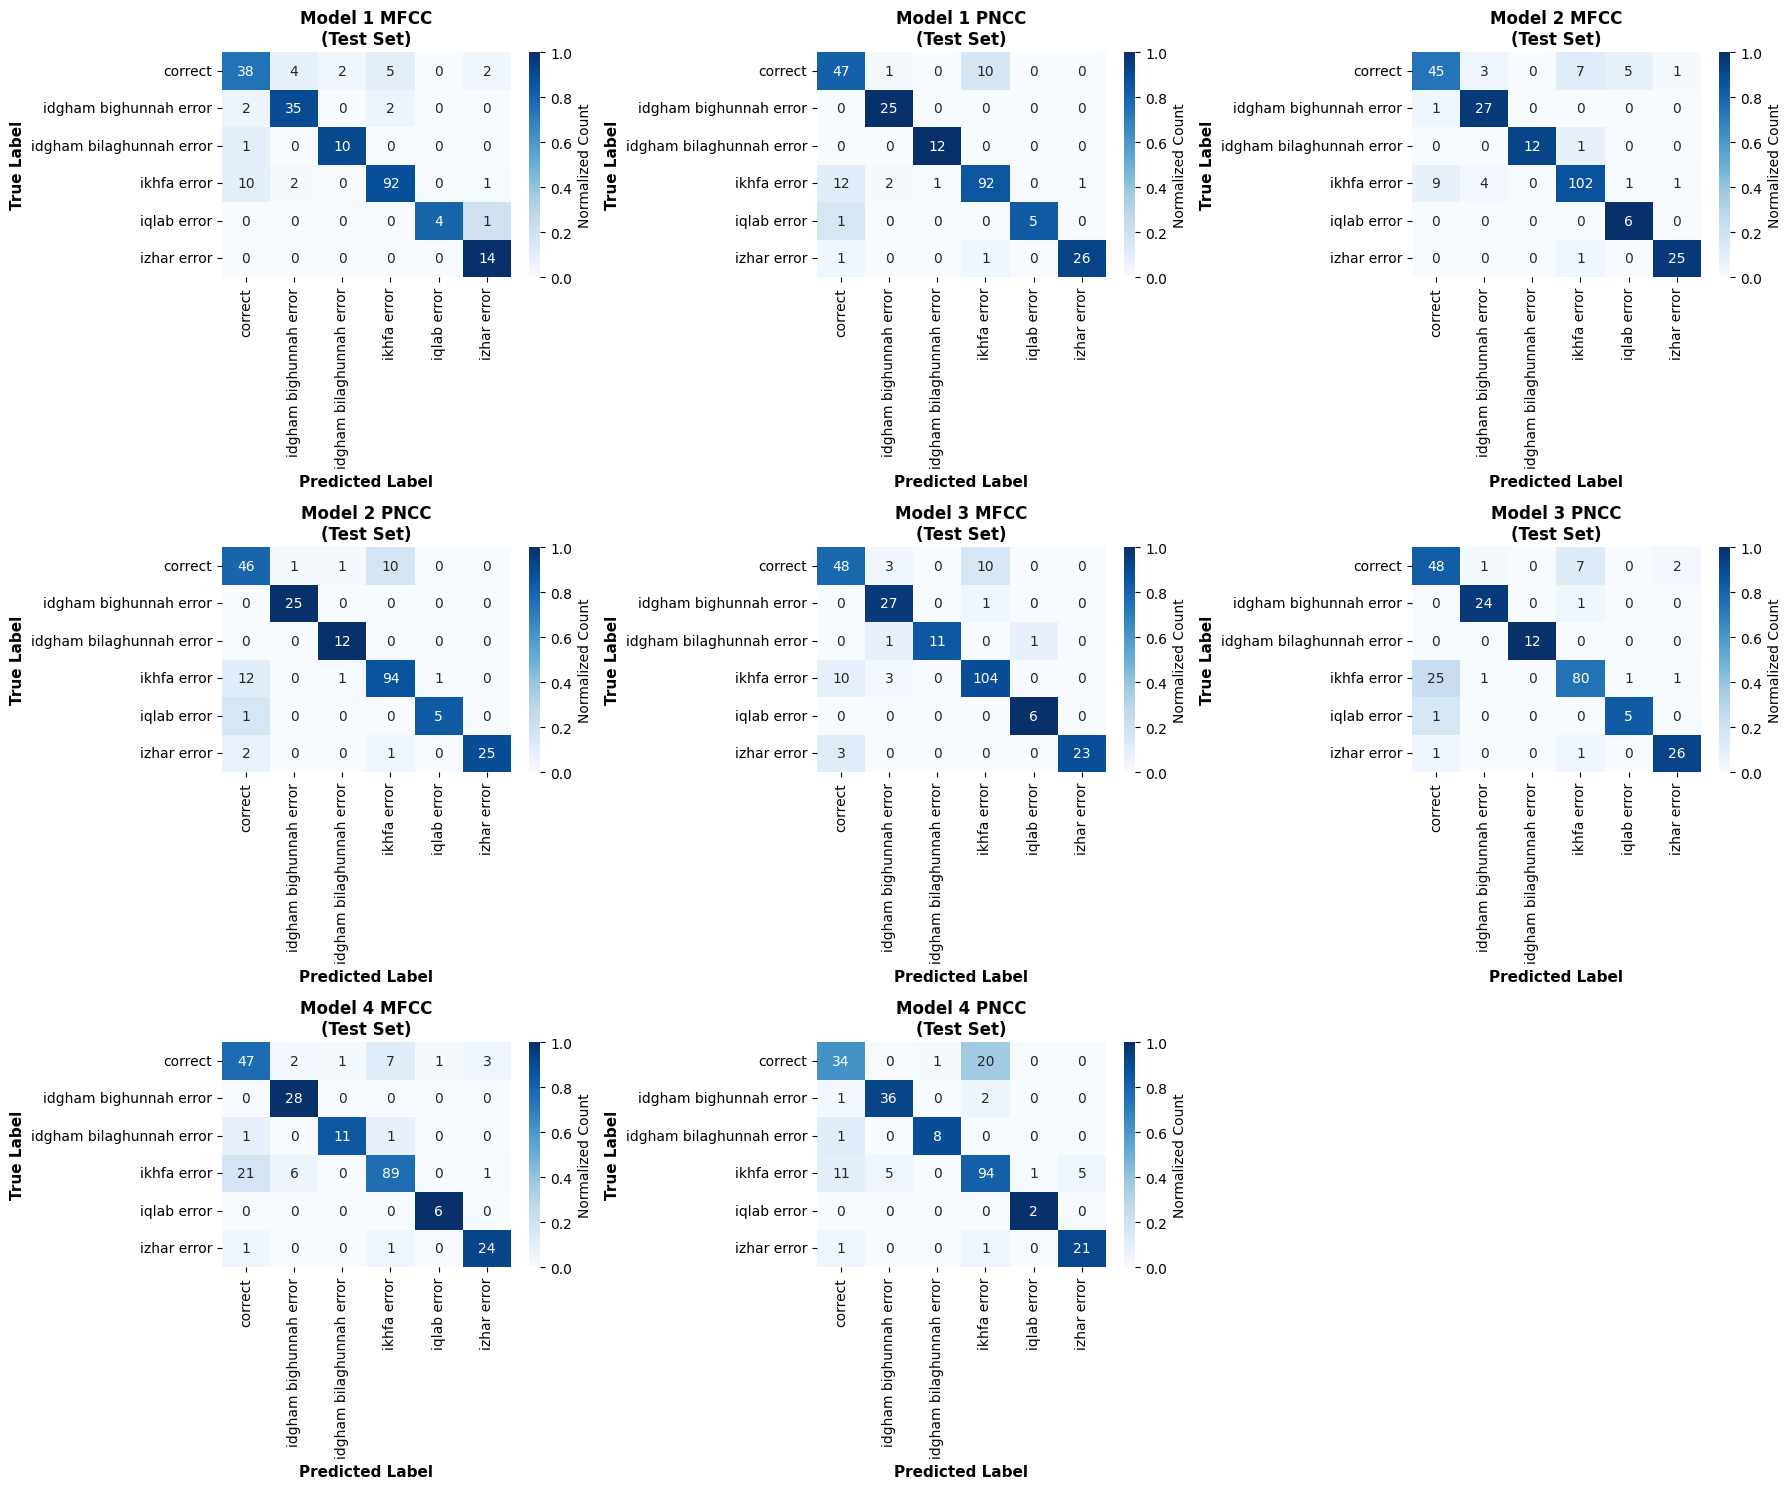


Test Set Confusion matrices visualized for all models.


In [207]:
# Ensure required imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualize confusion matrices for all models
num_models = len(aggregate_cm_all_models)
cols = 3
rows = (num_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows))
if num_models == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (model, cm) in enumerate(sorted(aggregate_cm_all_models.items())):
    ax = axes[idx]
    
    # Normalize confusion matrix for better visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create heatmap
    sns.heatmap(cm_normalized, 
                annot=cm,  # Show original counts
                fmt='d', 
                cmap='Blues', 
                cbar=True,
                ax=ax,
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Normalized Count'})
    
    ax.set_title(f'{model}\n(Test Set)', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# Hide unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\nTest Set Confusion matrices visualized for all models.")

In [208]:
import os
import shutil

# Define our target output directory for Kaggle downloads
destination_dir = '/kaggle/working/'
os.makedirs(destination_dir, exist_ok=True)

# Look for common model formats (.keras or .h5) generated during training
model_extensions = ('.keras', '.h5')
moved_models_count = 0

print("="*50)
print("EXPORTING SAVED MODELS TO KAGGLE WORKING DIR".center(50))
print("="*50)

# Scan current directory for model files
for file_name in os.listdir('.'):
    if file_name.endswith(model_extensions):
        source_path = os.path.join('.', file_name)
        destination_path = os.path.join(destination_dir, file_name)
        
        # Prevent copying a file onto itself if it was already saved directly in working
        if os.path.abspath(source_path) != os.path.abspath(destination_path):
            try:
                shutil.copy2(source_path, destination_path)
                print(f"✅ Successfully exported: {file_name} -> {destination_dir}")
                moved_models_count += 1
            except Exception as e:
                print(f"❌ Failed to copy {file_name}: {e}")
        else:
            print(f"ℹ️ Model already exists in destination: {file_name}")
            moved_models_count += 1

if moved_models_count == 0:
    print("⚠️ No saved model files found in the current root directory.")
    print("   Make sure your training callbacks/save functions ran successfully.")
else:
    print(f"\n🎉 Total models ready for download in /kaggle/working/: {moved_models_count}")
print("="*50)

   EXPORTING SAVED MODELS TO KAGGLE WORKING DIR   
ℹ️ Model already exists in destination: model4_mfcc.keras
ℹ️ Model already exists in destination: model1_pncc.keras
ℹ️ Model already exists in destination: model2_mfcc.keras
ℹ️ Model already exists in destination: model1_mfcc.keras
ℹ️ Model already exists in destination: model2_pncc.keras
ℹ️ Model already exists in destination: model4_pncc.keras
ℹ️ Model already exists in destination: model3_mfcc.keras
ℹ️ Model already exists in destination: model3_pncc.keras

🎉 Total models ready for download in /kaggle/working/: 8
